# **1. Giới thiệu dự án (Introduction)**

## **1.1. Bối cảnh kinh doanh & Vấn đề của công ty Fintech**
Trong bối cảnh nền kinh tế Việt Nam đang phục hồi và tầng lớp trung lưu gia tăng mạnh mẽ, nhu cầu vay tiêu dùng tín chấp qua các nền tảng Fintech kỹ thuật số đang trở thành xu hướng tất yếu. Tuy nhiên, đi kèm với cơ hội mở rộng thị phần là bài toán quản trị rủi ro nợ xấu (Credit Default Risk).

## **1.2. Mục tiêu phân tích**
* Khám phá và phân tích tập dữ liệu 50.000 hồ sơ tín dụng để tìm ra các mẫu hành vi của khách hàng.

* Xây dựng mô hình Học máy (Machine Learning) để định lượng rủi ro vỡ nợ của từng cá nhân.

* Ứng dụng ma trận Thị phần - Tăng trưởng (Growth-Share Matrix) nhằm đề xuất phân khúc khách hàng (Market Segment) mang lại biên độ lợi nhuận cao nhất với rủi ro thấp nhất cho công ty.

# **2. Tiền xử lý dữ liệu (Data Preprocessing & Cleaning)**

## **2.1. Khai báo thư viện (Import Libraries)**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Các thư viện cho Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap # Thư viện giải thích mô hình

## **2.2. Đọc và kiểm tra tổng quan dữ liệu**

In [12]:
#1. Đọc file excel
df = "/content/FBA 2025 - Customer credit data.xlsx"

# Đọc sheet 1
sheet1 = pd.read_excel(df, sheet_name="Sheet1")
print("=== Sheet1 ===")
print(sheet1)

# Đọc sheet 2
sheet2 = pd.read_excel(df, sheet_name="Sheet2")
print("\n=== Sheet2 ===")
print(sheet2)

=== Sheet1 ===
      customer_id  age                income_level employment_status  \
0      CUST-00001   65   Từ 8 - 20 triệu VND/tháng    Toàn thời gian   
1      CUST-00002   21   Từ 8 - 20 triệu VND/tháng    Toàn thời gian   
2      CUST-00003   59   Từ 8 - 20 triệu VND/tháng    Toàn thời gian   
3      CUST-00004   36   Từ 8 - 20 triệu VND/tháng     Bán thời gian   
4      CUST-00005   52   Từ 8 - 20 triệu VND/tháng    Toàn thời gian   
...           ...  ...                         ...               ...   
49995  CUST-49996   50  Từ 20 - 45 triệu VND/tháng    Toàn thời gian   
49996  CUST-49997   26   Từ 8 - 20 triệu VND/tháng     Bán thời gian   
49997  CUST-49998   45  Từ 20 - 45 triệu VND/tháng    Toàn thời gian   
49998  CUST-49999   46   Từ 8 - 20 triệu VND/tháng     Tự kinh doanh   
49999  CUST-50000   60  Từ 20 - 45 triệu VND/tháng       Thất nghiệp   

       years_at_current_job  credit_score  existing_debt_vnd  \
0                         8           551          64770

## **2.4. Khớp dữ liệu (Mapping) theo chuẩn**

In [13]:
# Gán df bằng dữ liệu từ Sheet1 để thực hiện làm sạch
df = sheet1.copy()

print("--- Bắt đầu làm sạch và chuẩn bị dữ liệu ---")

# 1. Kiểm tra các cột số tiền
print("\n1. Kiểm tra các cột số tiền:")
print(f"Kiểu dữ liệu của 'existing_debt_vnd': {df['existing_debt_vnd'].dtype}")
print(f"Kiểu dữ liệu của 'requested_loan_amount_vnd': {df['requested_loan_amount_vnd'].dtype}")
print(f"Số giá trị thiếu trong 'existing_debt_vnd': {df['existing_debt_vnd'].isnull().sum()}")
print(f"Số giá trị thiếu trong 'requested_loan_amount_vnd': {df['requested_loan_amount_vnd'].isnull().sum()}")

# 2. Chuyển đổi cột 'income_level' sang các nhóm
print("\n2. Chuyển đổi cột 'income_level' sang các nhóm:")

# Do Sheet 1 có đuôi '/tháng' còn Sheet 2 thì không, ta sẽ tạo mapping thủ công dựa trên nội dung Sheet 2 để đảm bảo chính xác
income_level_mapping = {
    'Dưới 8 triệu VND/tháng': 'Thấp (Low)',
    'Từ 8 - 20 triệu VND/tháng': 'Trung bình (Medium)',
    'Từ 20 - 45 triệu VND/tháng': 'Cao (High)',
    'Trên 45 triệu VND/tháng': 'Rất cao (Very High)'
}

# Ánh xạ giá trị
df['income_level_group'] = df['income_level'].map(income_level_mapping)

# Thiết lập thứ tự phân loại
income_level_categories = ['Thấp (Low)', 'Trung bình (Medium)', 'Cao (High)', 'Rất cao (Very High)']
df['income_level_group'] = pd.Categorical(df['income_level_group'], categories=income_level_categories, ordered=True)

print("Giá trị duy nhất và số lượng của 'income_level_group':")
print(df['income_level_group'].value_counts())

# 3. Chuyển đổi cột 'credit_score' sang các nhóm dựa trên Sheet 2.
print("\n3. Chuyển đổi cột 'credit_score' sang các nhóm:")
# Định nghĩa bins: 300-579 (Kém), 580-669 (Trung bình), 670-739 (Tốt), 740-799 (Rất tốt), 800-850 (Xuất sắc)
bins = [299, 579, 669, 739, 799, 850]
labels = ['Kém (Poor)', 'Trung bình (Fair)', 'Tốt (Good)', 'Rất tốt (Very Good)', 'Xuất sắc (Excellent)']

df['credit_score_group'] = pd.cut(df['credit_score'], bins=bins, labels=labels, right=True, include_lowest=True)

print("Giá trị duy nhất và số lượng của 'credit_score_group':")
print(df['credit_score_group'].value_counts())

print("\n--- Hoàn thành làm sạch và chuẩn bị dữ liệu ---")
print(df[['income_level', 'income_level_group', 'credit_score', 'credit_score_group']].head())

--- Bắt đầu làm sạch và chuẩn bị dữ liệu ---

1. Kiểm tra các cột số tiền:
Kiểu dữ liệu của 'existing_debt_vnd': int64
Kiểu dữ liệu của 'requested_loan_amount_vnd': int64
Số giá trị thiếu trong 'existing_debt_vnd': 0
Số giá trị thiếu trong 'requested_loan_amount_vnd': 0

2. Chuyển đổi cột 'income_level' sang các nhóm:
Giá trị duy nhất và số lượng của 'income_level_group':
income_level_group
Trung bình (Medium)    22375
Thấp (Low)             14914
Cao (High)             10209
Rất cao (Very High)     2502
Name: count, dtype: int64

3. Chuyển đổi cột 'credit_score' sang các nhóm:
Giá trị duy nhất và số lượng của 'credit_score_group':
credit_score_group
Trung bình (Fair)       18908
Tốt (Good)              13445
Kém (Poor)               9413
Rất tốt (Very Good)      5950
Xuất sắc (Excellent)     2284
Name: count, dtype: int64

--- Hoàn thành làm sạch và chuẩn bị dữ liệu ---
                income_level   income_level_group  credit_score  \
0  Từ 8 - 20 triệu VND/tháng  Trung bình (Medium)

## **2.3. Chuẩn hóa dữ liệu**

In [14]:
print("kiểm tra giá trị thiếu:")
print(sheet1.isnull().sum())
print("Số dòng trùng lặp:")
print(sheet1.duplicated().sum())

kiểm tra giá trị thiếu:
customer_id                  0
age                          0
income_level                 0
employment_status            0
years_at_current_job         0
credit_score                 0
existing_debt_vnd            0
savings_amount_vnd           0
home_ownership_status        0
loan_purpose                 0
requested_loan_amount_vnd    0
loan_term_months             0
default_status               0
dtype: int64
Số dòng trùng lặp:
0


In [15]:
# 1. Loại bỏ khoảng trắng thừa
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Mã hóa nợ xấu (Dành cho BA tính toán tỷ lệ)
df['is_defaulted'] = df['default_status'].map({'Defaulted': 1, 'Paid in full': 0})

# 3. Sử dụng pd.cut để chia nhóm Credit Score (thay cho hàm if-elif)
bins = [300, 580, 670, 740, 800, 850]
labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
df['credit_rating'] = pd.cut(df['credit_score'], bins=bins, labels=labels, right=False)

Tập dữ liệu ban đầu cho thấy chất lượng thu thập rất tốt: không ghi nhận các giá trị khuyết thiếu **(Null/NaN)** hay dữ liệu trùng lặp **(Duplicates)**. Tuy nhiên, để phục vụ cho việc trực quan hóa và đưa vào mô hình học máy, các biến phân loại (Categorical variables) như **income_level**, **credit_score** đã được chuẩn hóa lại format (loại bỏ khoảng trắng thừa) và ánh xạ (mapping) theo đúng thứ tự logic từ thấp đến cao.

# **3. Phân tích Khám phá Dữ liệu (Exploratory Data Analysis - EDA)**




--- Trực quan hóa các biến số ---


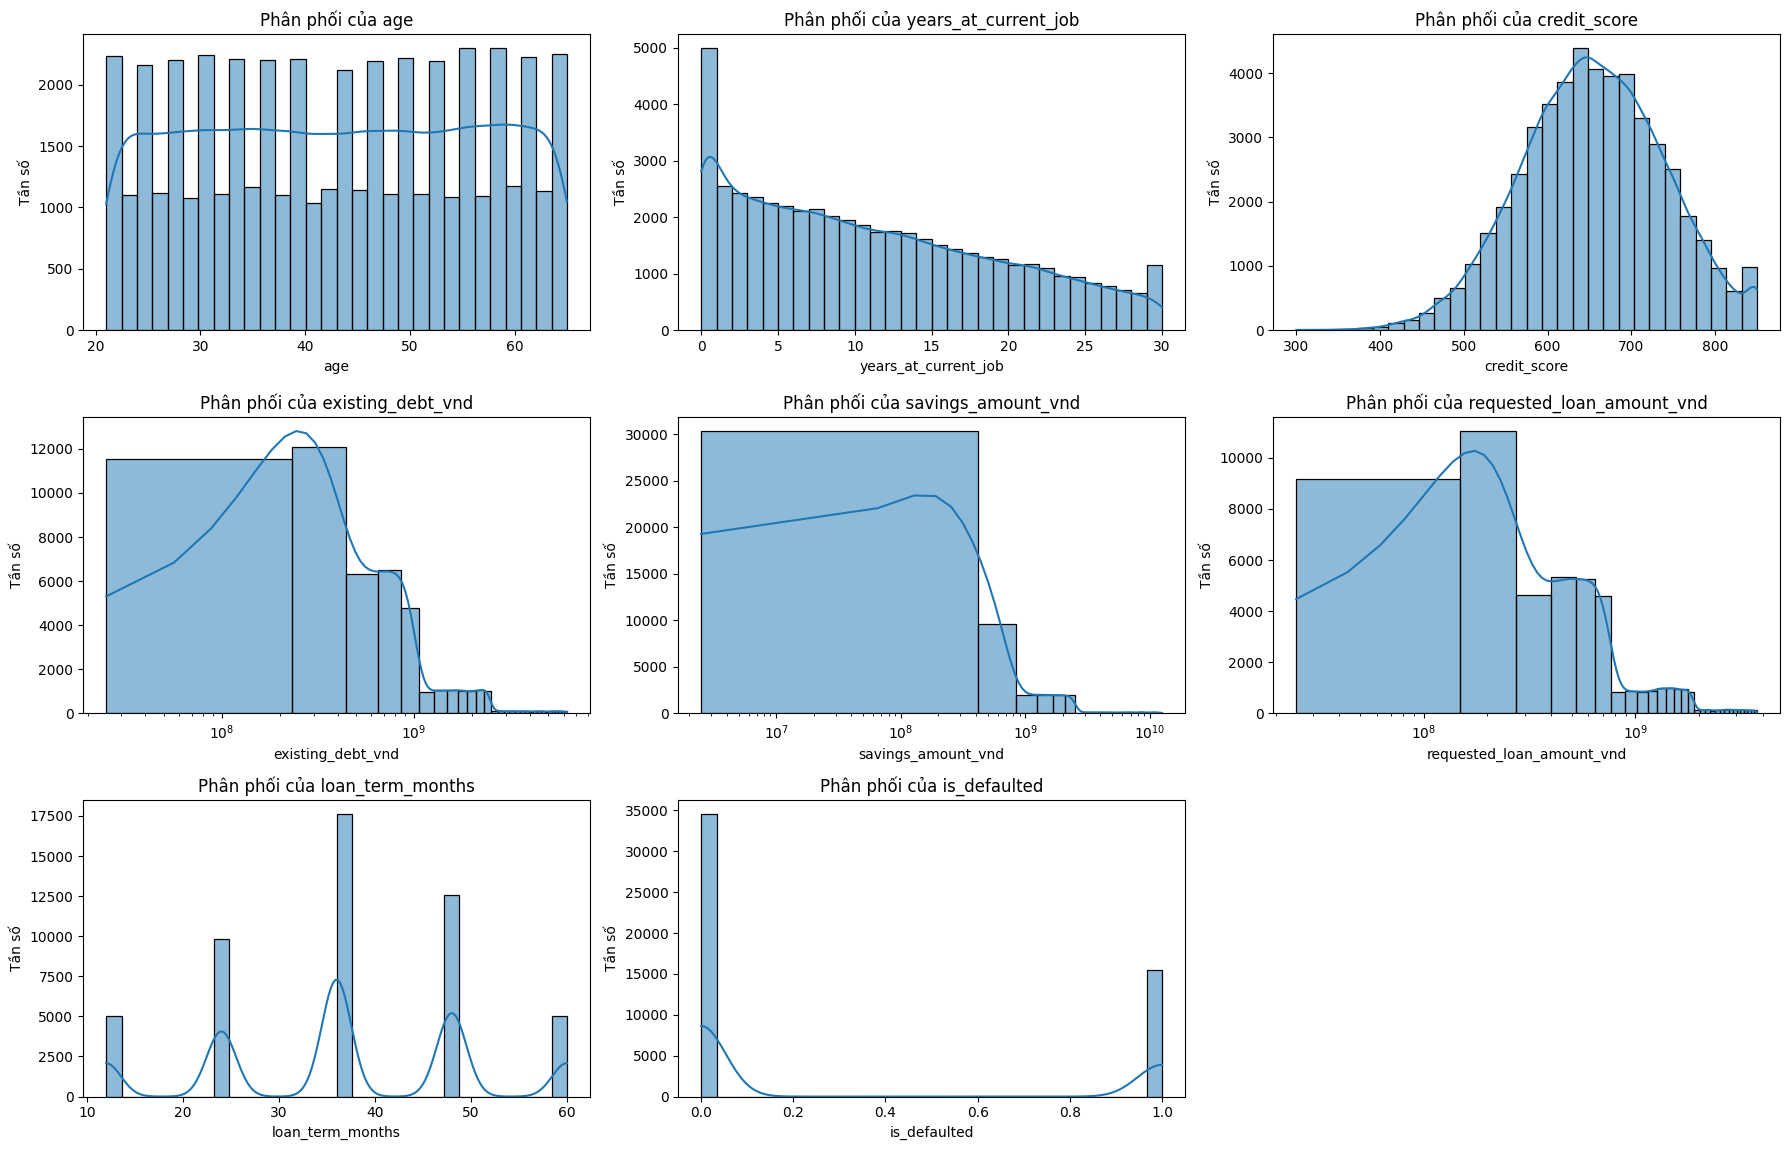


--- Trực quan hóa các biến phân loại ---


/tmp/ipykernel_807/2603512086.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_807/2603512086.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_807/2603512086.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_807/2603512086.py:33: FutureWarning: 

Passing `palette` without

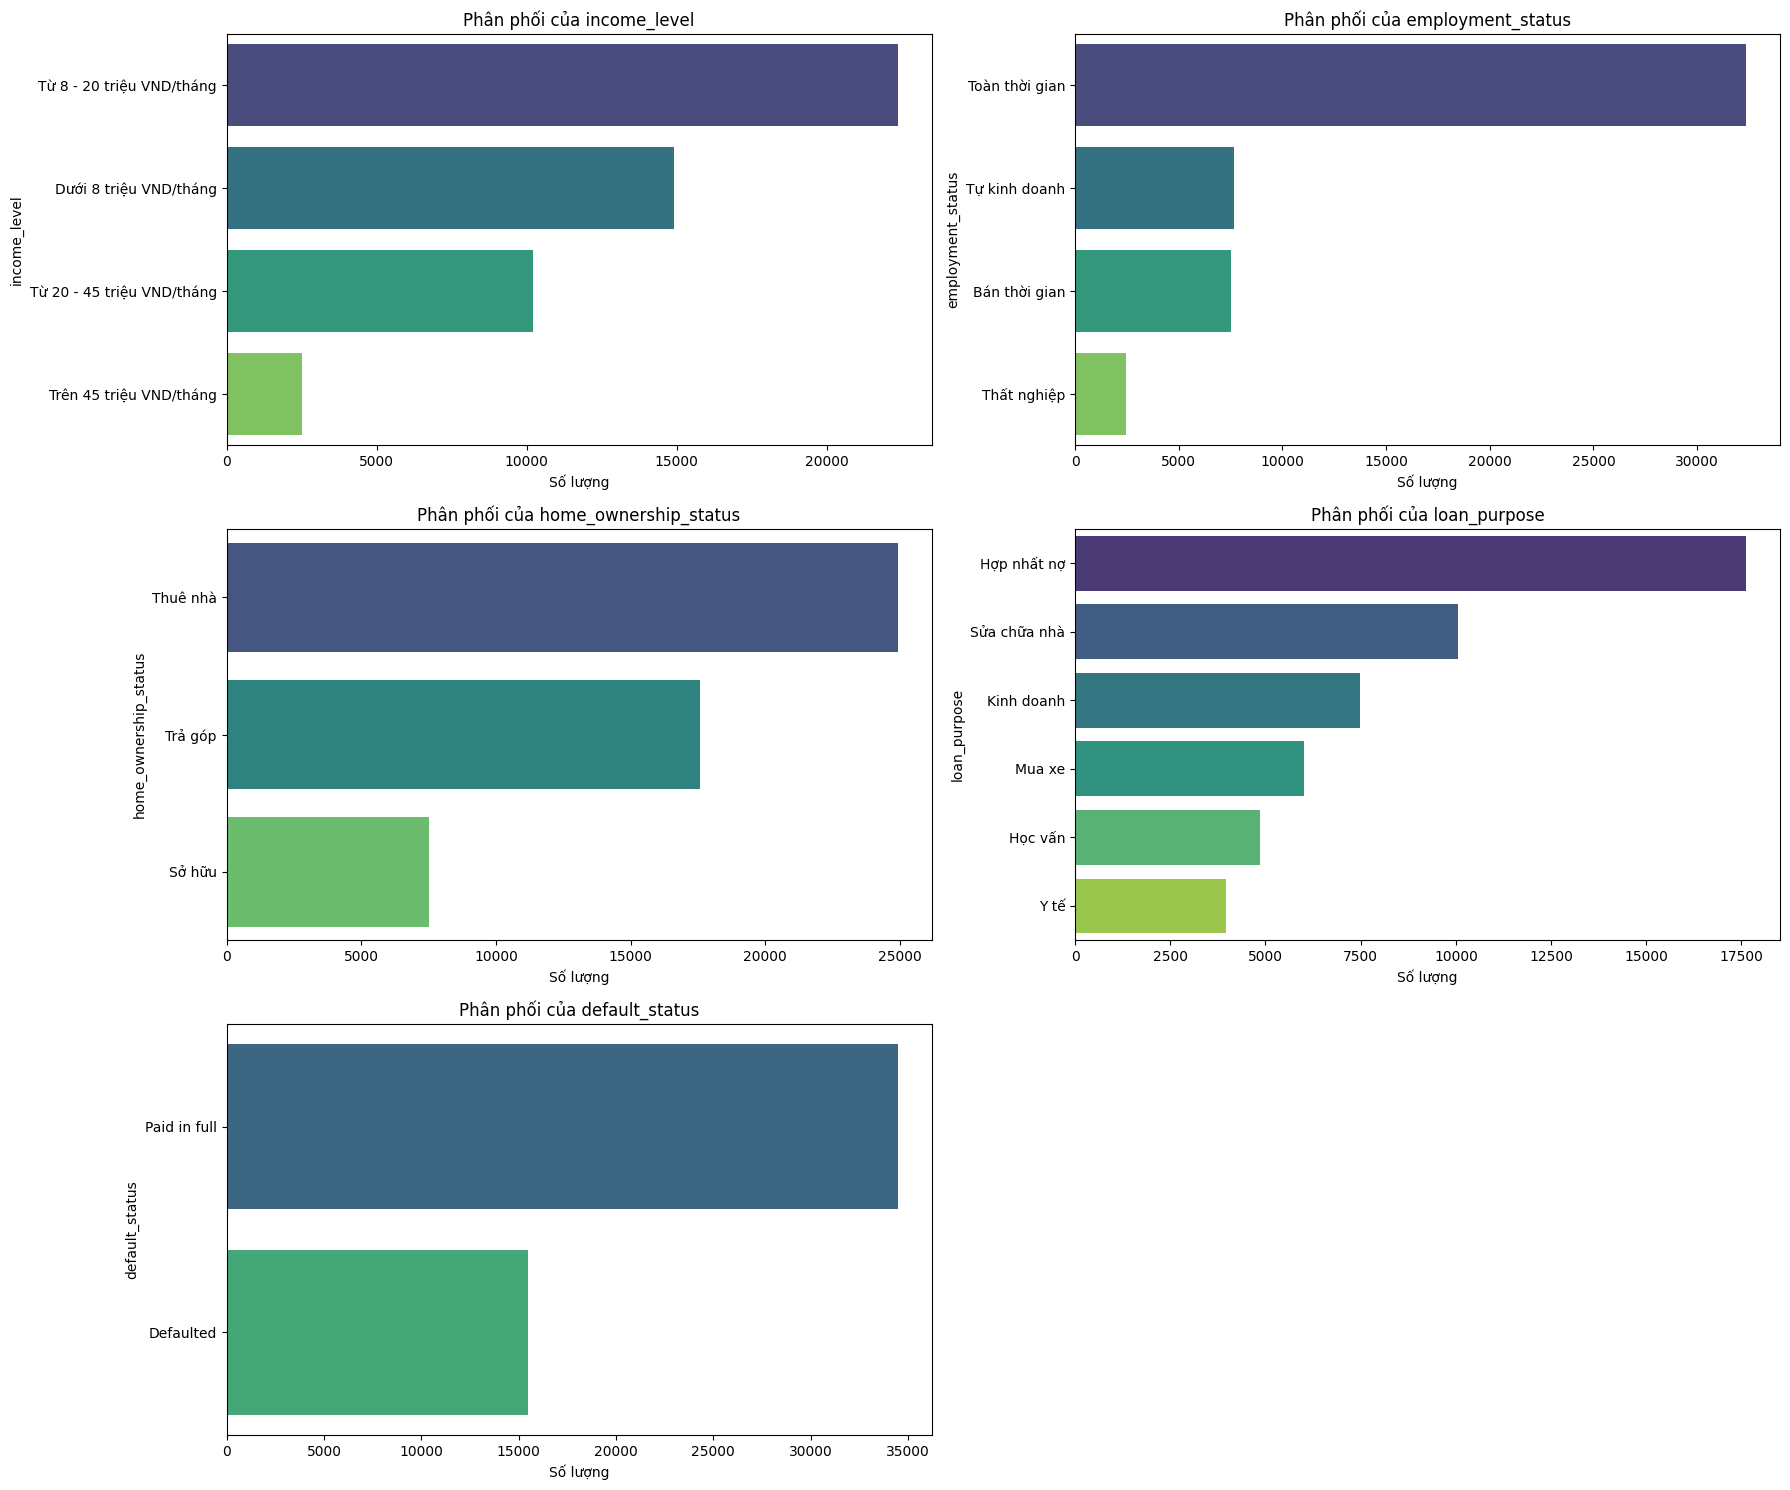


--- Mối quan hệ giữa Default Status và các biến phân loại ---


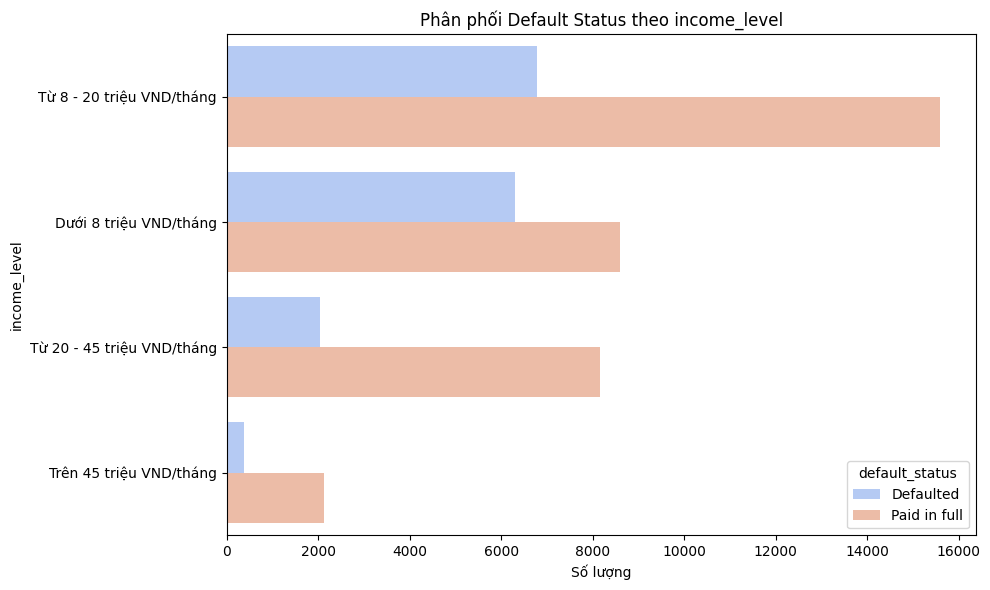

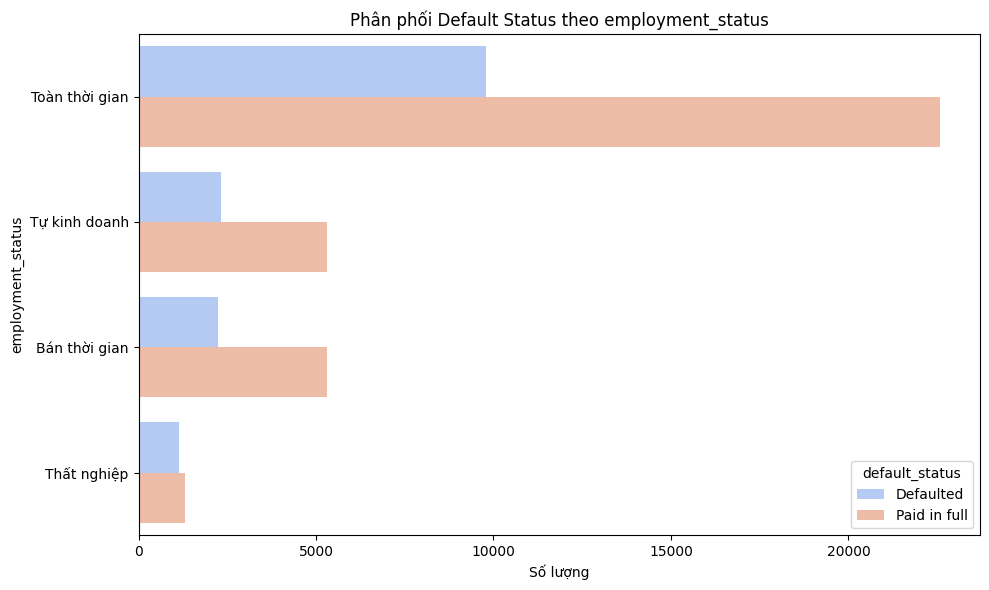

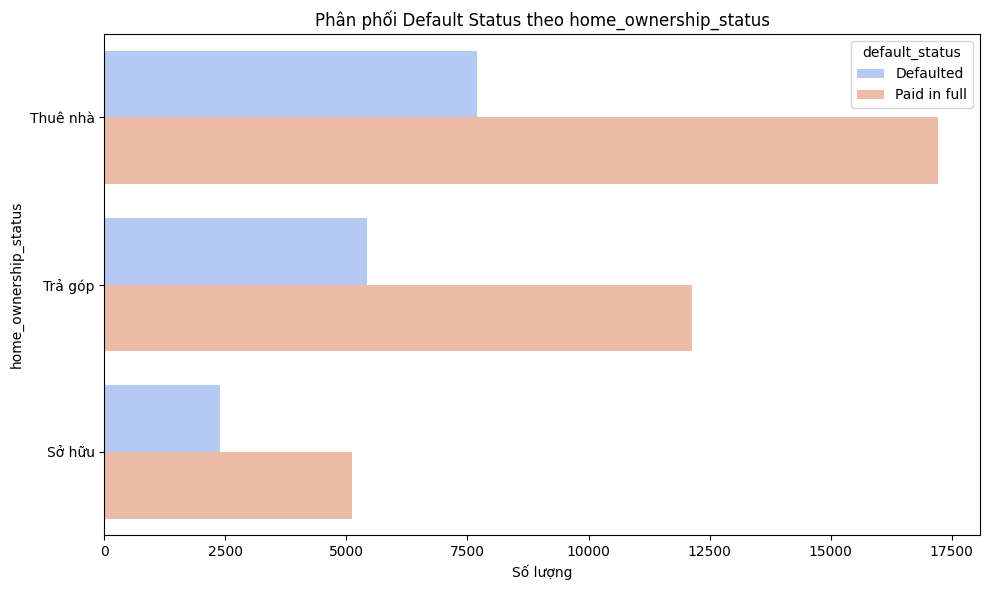

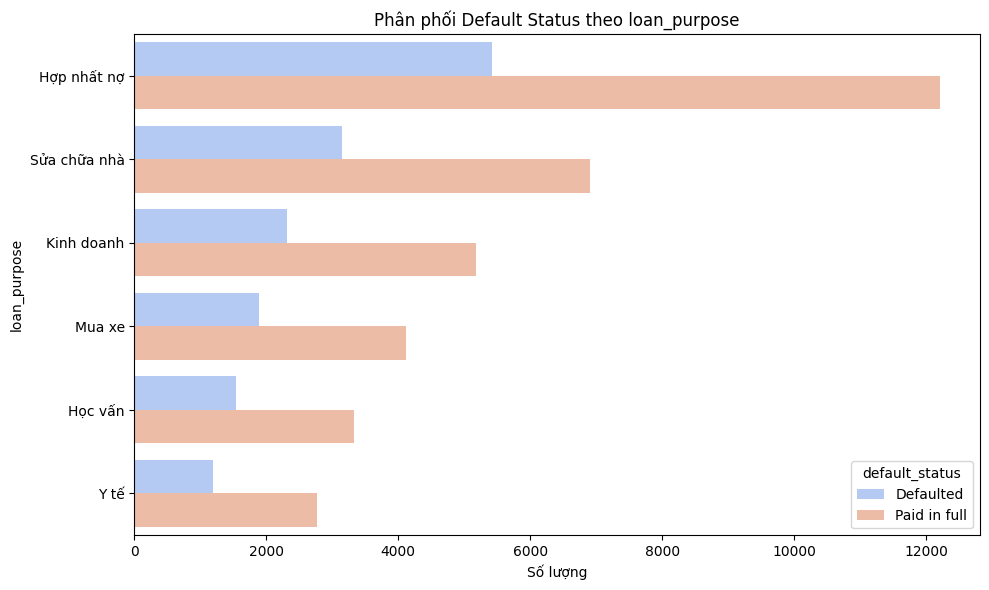

In [16]:
# 1. Trực quan hóa các biến số (Numerical Features)
print("\n--- Trực quan hóa các biến số ---")
# Sử dụng các cột số đã được xác định trước đó trong notebook, hoặc tự động chọn
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Loại bỏ các cột ID hoặc cột đã được mã hóa không cần trực quan hóa phân phối số
exclude_cols = ['customer_id', 'income_level_numeric', 'default_status_encoded', 'cluster']
num_cols = [col for col in num_cols if col not in exclude_cols and not col.endswith('_encoded')]

plt.figure(figsize=(18, 15))
for i, col in enumerate(num_cols):
    plt.subplot(round(len(num_cols)/3) + 1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Phân phối của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần số')
    # Áp dụng log scale cho các biến có giá trị lớn và phân bố lệch
    if 'vnd' in col or 'amount' in col or 'debt' in col:
        plt.xscale('log')
plt.tight_layout()
plt.show()

# 2. Trực quan hóa các biến phân loại (Categorical Features)
print("\n--- Trực quan hóa các biến phân loại ---")
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Loại bỏ customer_id không cần thiết cho EDA tổng quan
cat_cols = [col for col in cat_cols if col not in ['customer_id']]

plt.figure(figsize=(18, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(round(len(cat_cols)/2) + 1, 2, i + 1)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Phân phối của {col}')
    plt.xlabel('Số lượng')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# 3. Mối quan hệ giữa Default Status và các biến phân loại khác
print("\n--- Mối quan hệ giữa Default Status và các biến phân loại ---")
for col in cat_cols:
    if col != 'default_status':
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=col, hue='default_status', palette='coolwarm', order=df[col].value_counts().index)
        plt.title(f'Phân phối Default Status theo {col}')
        plt.xlabel('Số lượng')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


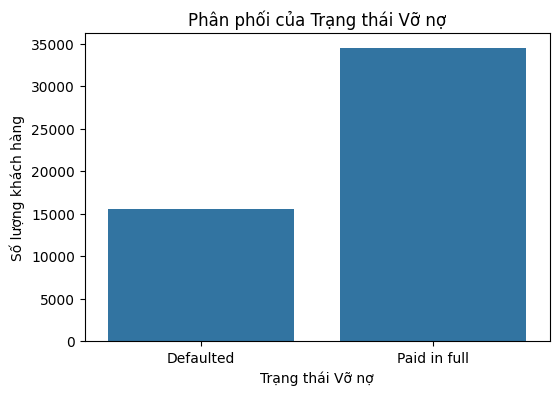


### 3.2. Phân tích theo Nhân khẩu học & Việc làm

#### Phân tích theo Độ tuổi


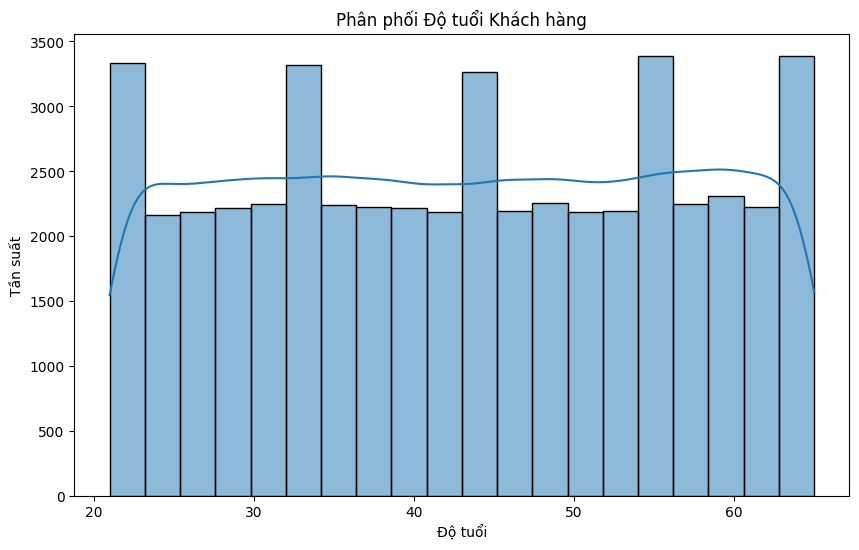

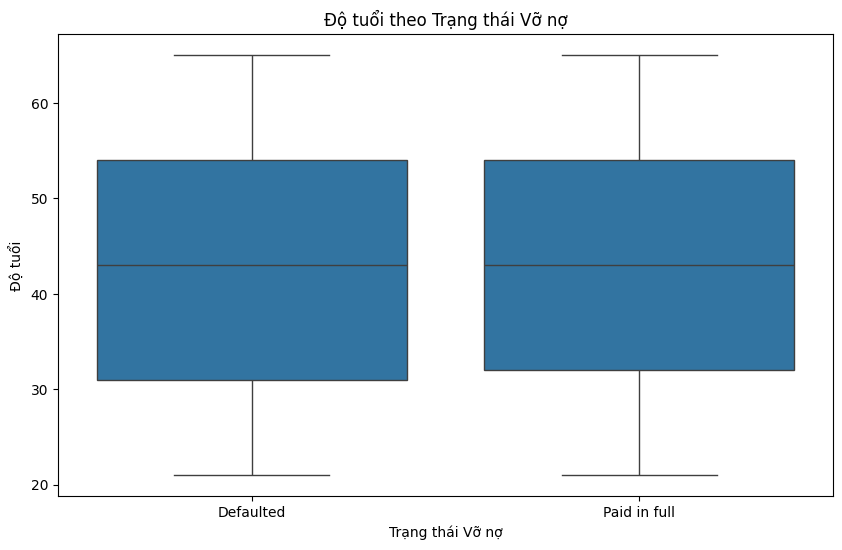


#### Phân tích theo Thu nhập


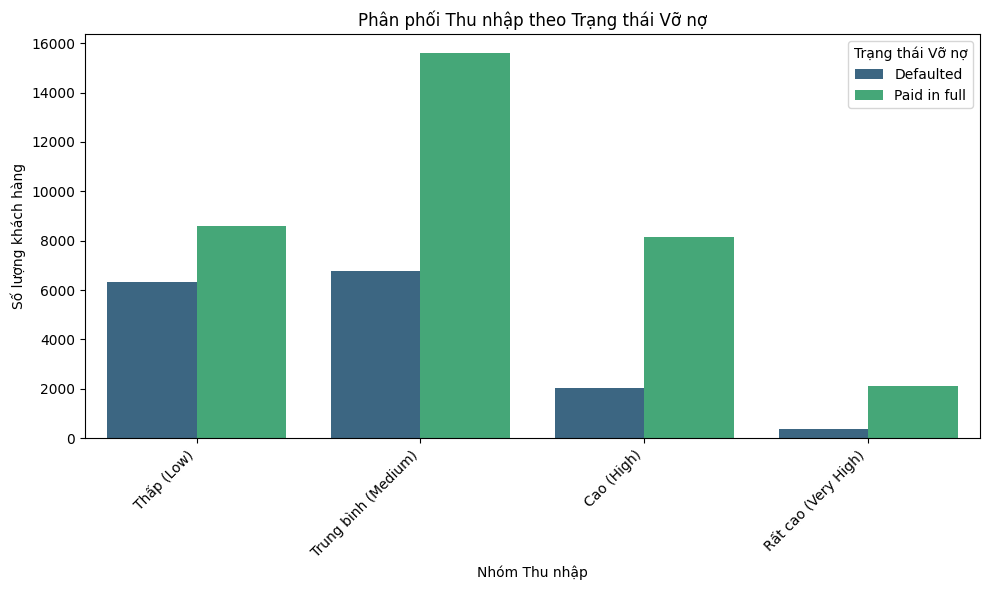


#### Phân tích theo Tình trạng việc làm


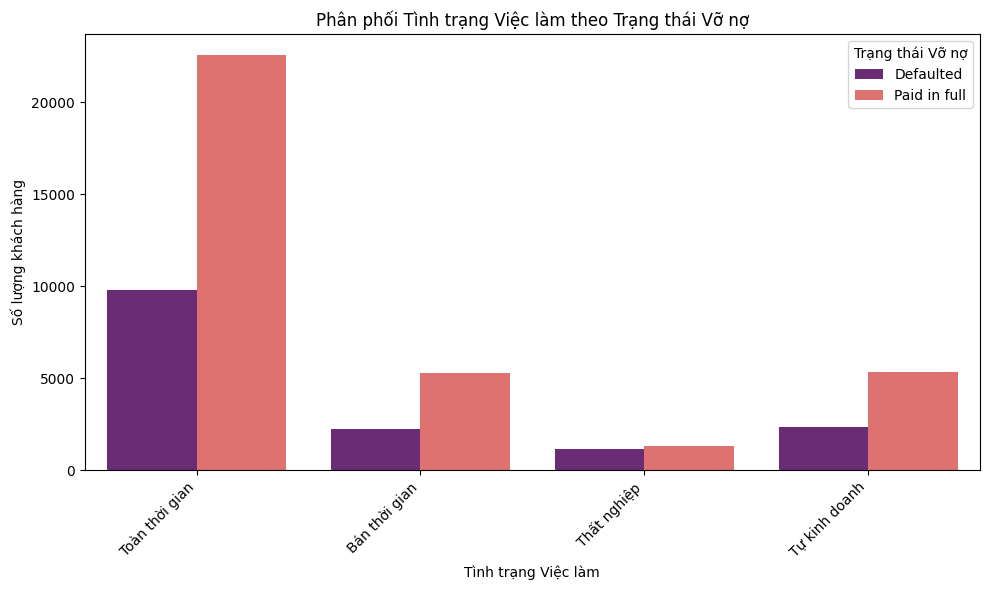


### 3.3. Phân tích theo Hành vi Tín dụng

#### Phân tích theo Điểm tín dụng


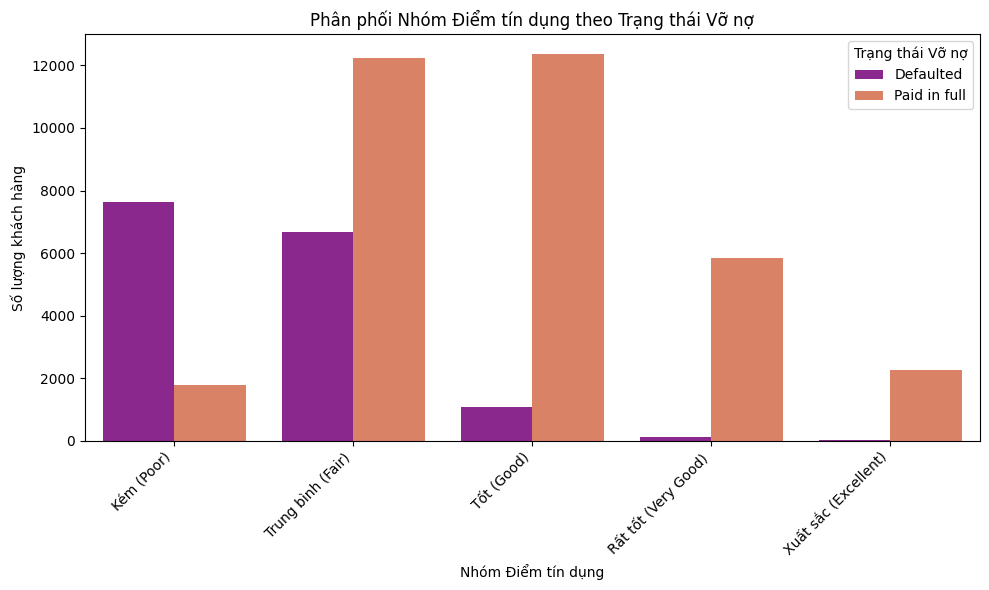


#### Phân tích theo Khoản tiết kiệm


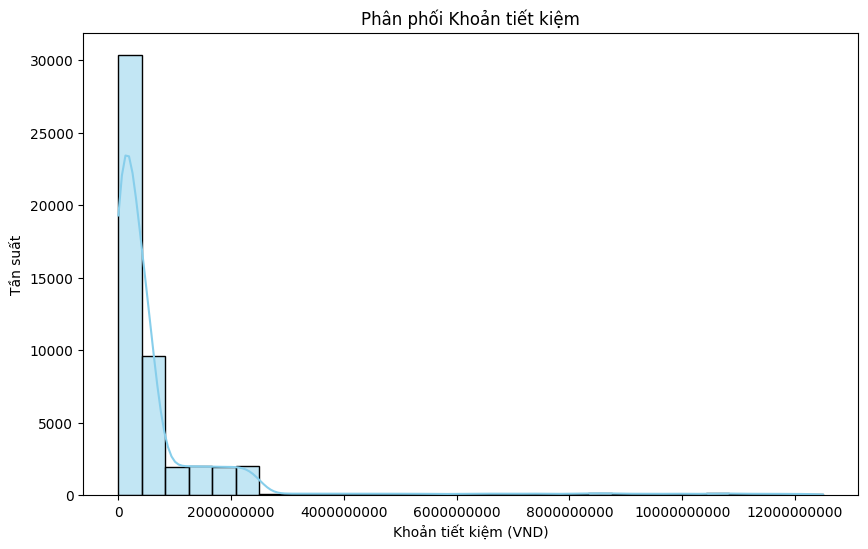

/tmp/ipykernel_807/672798665.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_status', y='savings_amount_vnd', data=df, palette='rocket')


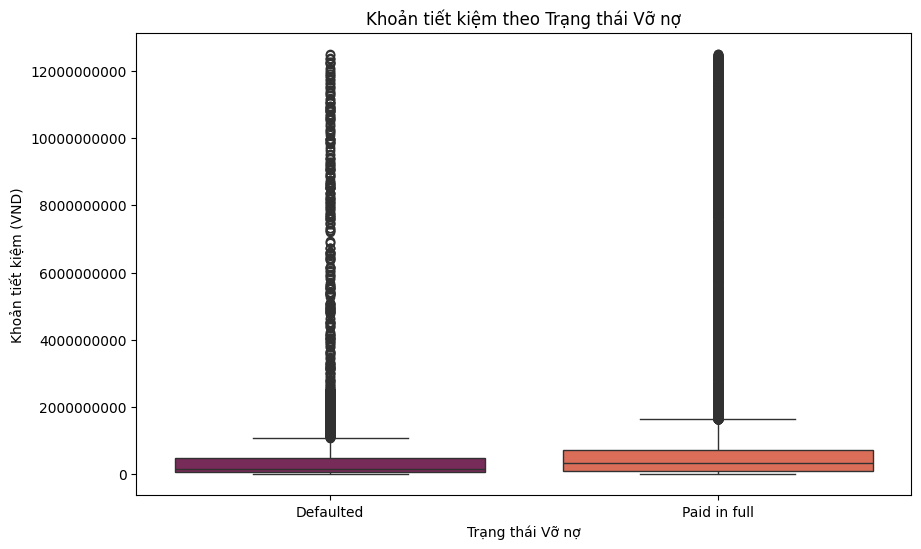


#### Phân tích theo Mục đích vay


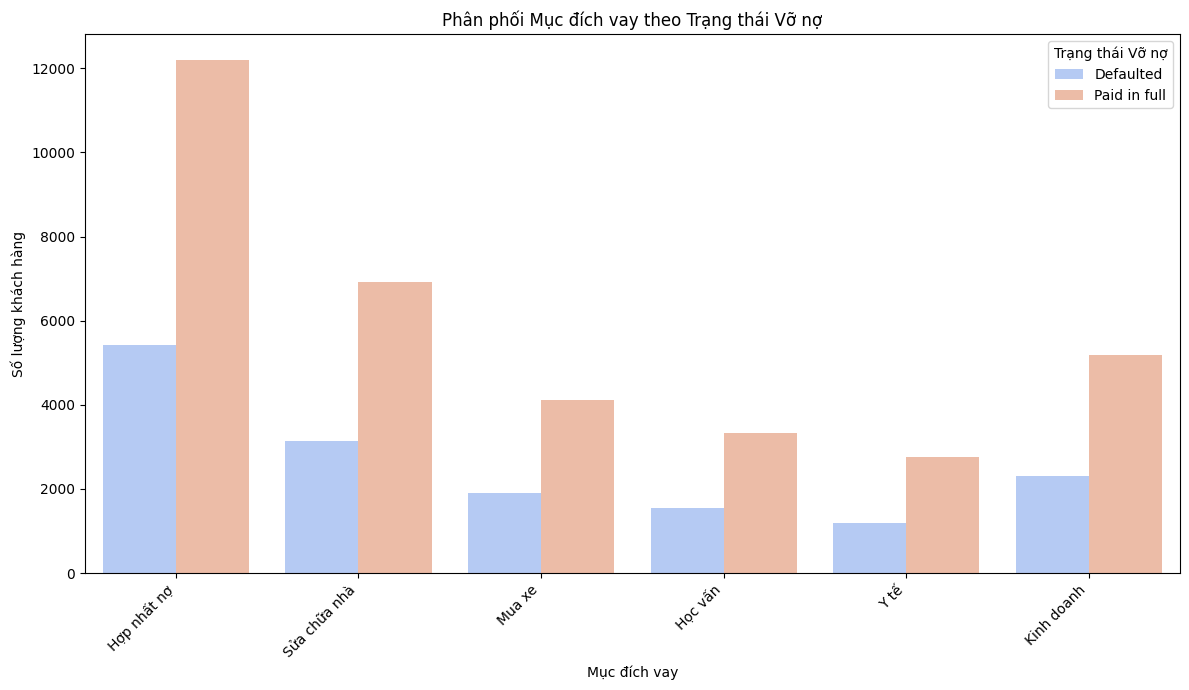


### 3.4. Ma trận tương quan giữa các biến số nguyên


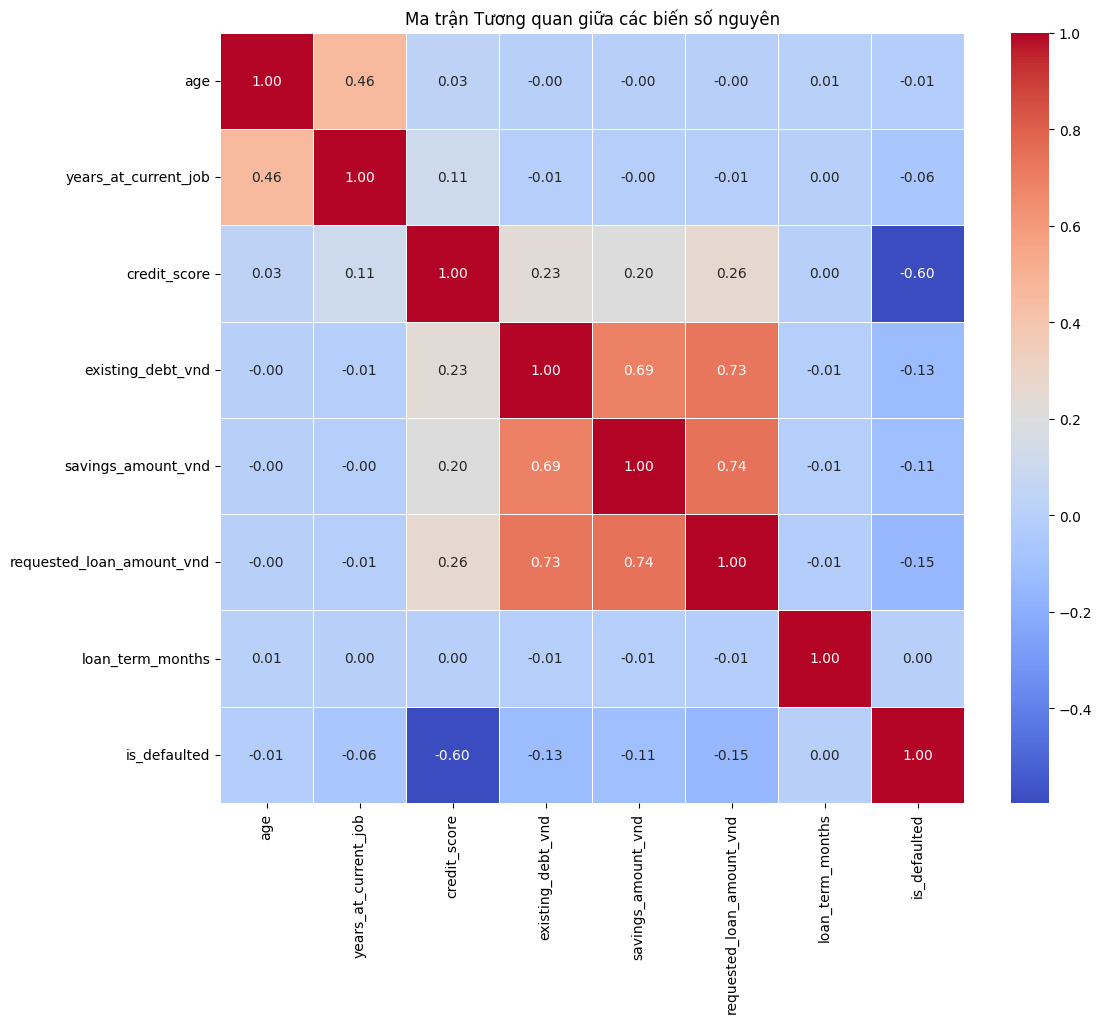

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='default_status', data=df) # Removed palette as hue is not used
plt.title('Phân phối của Trạng thái Vỡ nợ')
plt.xlabel('Trạng thái Vỡ nợ')
plt.ylabel('Số lượng khách hàng')
plt.show()

# 3.2. Phân tích theo Nhân khẩu học & Việc làm (Độ tuổi, Thu nhập, Tình trạng việc làm)
print("\n### 3.2. Phân tích theo Nhân khẩu học & Việc làm")

# Phân tích Độ tuổi
print("\n#### Phân tích theo Độ tuổi")
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True) # Removed palette as hue is not used
plt.title('Phân phối Độ tuổi Khách hàng')
plt.xlabel('Độ tuổi')
plt.ylabel('Tần suất')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='default_status', y='age', data=df) # Removed palette as hue is not used
plt.title('Độ tuổi theo Trạng thái Vỡ nợ')
plt.xlabel('Trạng thái Vỡ nợ')
plt.ylabel('Độ tuổi')
plt.show()

# Phân tích Thu nhập
print("\n#### Phân tích theo Thu nhập")
plt.figure(figsize=(10, 6))
sns.countplot(x='income_level_group', hue='default_status', data=df, palette='viridis', order=df['income_level_group'].cat.categories)
plt.title('Phân phối Thu nhập theo Trạng thái Vỡ nợ')
plt.xlabel('Nhóm Thu nhập')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trạng thái Vỡ nợ')
plt.tight_layout()
plt.show()

# Phân tích Tình trạng việc làm
print("\n#### Phân tích theo Tình trạng việc làm")
plt.figure(figsize=(10, 6))
sns.countplot(x='employment_status', hue='default_status', data=df, palette='magma')
plt.title('Phân phối Tình trạng Việc làm theo Trạng thái Vỡ nợ')
plt.xlabel('Tình trạng Việc làm')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trạng thái Vỡ nợ')
plt.tight_layout()
plt.show()
# 3.3. Phân tích theo Hành vi Tín dụng (Điểm tín dụng, Khoản tiết kiệm, Mục đích vay)
print("\n### 3.3. Phân tích theo Hành vi Tín dụng")

# Phân tích Điểm tín dụng
print("\n#### Phân tích theo Điểm tín dụng")
plt.figure(figsize=(10, 6))
sns.countplot(x='credit_score_group', hue='default_status', data=df, palette='plasma', order=df['credit_score_group'].cat.categories)
plt.title('Phân phối Nhóm Điểm tín dụng theo Trạng thái Vỡ nợ')
plt.xlabel('Nhóm Điểm tín dụng')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trạng thái Vỡ nợ')
plt.tight_layout()
plt.show()

# Phân tích Khoản tiết kiệm
print("\n#### Phân tích theo Khoản tiết kiệm")
plt.figure(figsize=(10, 6))
sns.histplot(df['savings_amount_vnd'], bins=30, kde=True, color='skyblue') # color argument is fine
plt.title('Phân phối Khoản tiết kiệm')
plt.xlabel('Khoản tiết kiệm (VND)')
plt.ylabel('Tần suất')
plt.ticklabel_format(style='plain', axis='x') # Avoid scientific notation on x-axis
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='default_status', y='savings_amount_vnd', data=df, palette='rocket')
plt.title('Khoản tiết kiệm theo Trạng thái Vỡ nợ')
plt.xlabel('Trạng thái Vỡ nợ')
plt.ylabel('Khoản tiết kiệm (VND)')
plt.ticklabel_format(style='plain', axis='y') # Avoid scientific notation on y-axis
plt.show()

# Ghi chú: Thêm đoạn Markdown với kết luận sau các biểu đồ này.
# Ví dụ:
# '''
# **Kết luận 3.3.2 (Khoản tiết kiệm):** Biểu đồ phân phối cho thấy phần lớn khách hàng có khoản tiết kiệm thấp.
# Biểu đồ boxplot có thể chỉ ra rằng những khách hàng vỡ nợ có khoản tiết kiệm trung bình thấp hơn hoặc phân phối khác biệt so với nhóm thanh toán đầy đủ.
# '''

# Phân tích Mục đích vay
print("\n#### Phân tích theo Mục đích vay")
plt.figure(figsize=(12, 7))
sns.countplot(x='loan_purpose', hue='default_status', data=df, palette='coolwarm')
plt.title('Phân phối Mục đích vay theo Trạng thái Vỡ nợ')
plt.xlabel('Mục đích vay')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trạng thái Vỡ nợ')
plt.tight_layout()
plt.show()

# 3.4. Ma trận tương quan (Correlation Matrix) giữa các biến số nguyên
print("\n### 3.4. Ma trận tương quan giữa các biến số nguyên")

# Chọn các cột số nguyên hoặc số thực
numerical_cols = df.select_dtypes(include=np.number).columns

# Cần đảm bảo 'is_defaulted' (đã được tạo từ 'default_status') là dạng số để đưa vào ma trận tương quan.
# Các cột số tiền có thể có mối tương quan mạnh.
cols_for_corr = ['age', 'years_at_current_job', 'credit_score',
                 'existing_debt_vnd', 'savings_amount_vnd', 'requested_loan_amount_vnd',
                 'loan_term_months', 'is_defaulted']

# Đảm bảo chỉ chọn các cột có trong DataFrame
actual_cols_for_corr = [col for col in cols_for_corr if col in df.columns]

if len(actual_cols_for_corr) > 1:
    correlation_matrix = df[actual_cols_for_corr].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Ma trận Tương quan giữa các biến số nguyên')
    plt.show()
else:
    print("Không đủ cột số để tạo ma trận tương quan.")

Dựa trên phân tích EDA đã thực hiện, đây là một số nhận xét chính:

1.  **Tỷ lệ nợ xấu chung**: Khoảng 31.01% tổng số khách hàng đã bị nợ xấu (Defaulted).
2.  **Mối liên hệ giữa thu nhập và nợ xấu**: Có một mối tương quan rõ rệt giữa mức thu nhập và tỷ lệ nợ xấu. Các nhóm thu nhập thấp có tỷ lệ nợ xấu cao hơn đáng kể (ví dụ: nhóm 'Thấp (Low)' có tỷ lệ nợ xấu khoảng 42.32%), trong khi các nhóm thu nhập cao hơn có tỷ lệ nợ xấu thấp hơn nhiều (ví dụ: nhóm 'Rất cao (Very High)' chỉ khoảng 14.87%). Điều này cho thấy thu nhập là một yếu tố dự báo mạnh mẽ về khả năng trả nợ.
3.  **Mục đích vay và nợ xấu**: Tỷ lệ nợ xấu không có sự khác biệt quá lớn giữa các mục đích vay. Các mục đích như 'Học vấn' và 'Mua xe' có tỷ lệ nợ xấu nhỉnh hơn một chút, trong khi 'Y tế' có tỷ lệ thấp hơn.
4.  **Độ tuổi và nợ xấu**: Khách hàng trẻ tuổi (20-30) có tỷ lệ nợ xấu cao hơn một chút (khoảng 32.77%) so với nhóm trung niên và lớn tuổi hơn (khoảng 30.5%).

Các biểu đồ phân phối biến số cho thấy dữ liệu tương đối cân bằng và không có các giá trị thiếu (null) đáng kể, giúp đảm bảo chất lượng cho các phân tích tiếp theo.

### **EDA Nâng cao: Phân tích Sức khỏe Tài chính và Rủi ro Vỡ nợ**

Phần này sẽ đi sâu vào các tỷ lệ tài chính quan trọng để hiểu rõ hơn sự khác biệt giữa khách hàng trả nợ đúng hạn và khách hàng vỡ nợ.


--- Phân tích Tỷ lệ Tài chính theo Trạng thái Nợ xấu ---


/tmp/ipykernel_807/4252778308.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='default_status', y=col, data=df, palette='coolwarm')
/tmp/ipykernel_807/4252778308.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='default_status', y=col, data=df, palette='coolwarm')
/tmp/ipykernel_807/4252778308.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='default_status', y=col, data=df, palette='coolwarm')
/tmp/ipykernel_807/4252778308.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

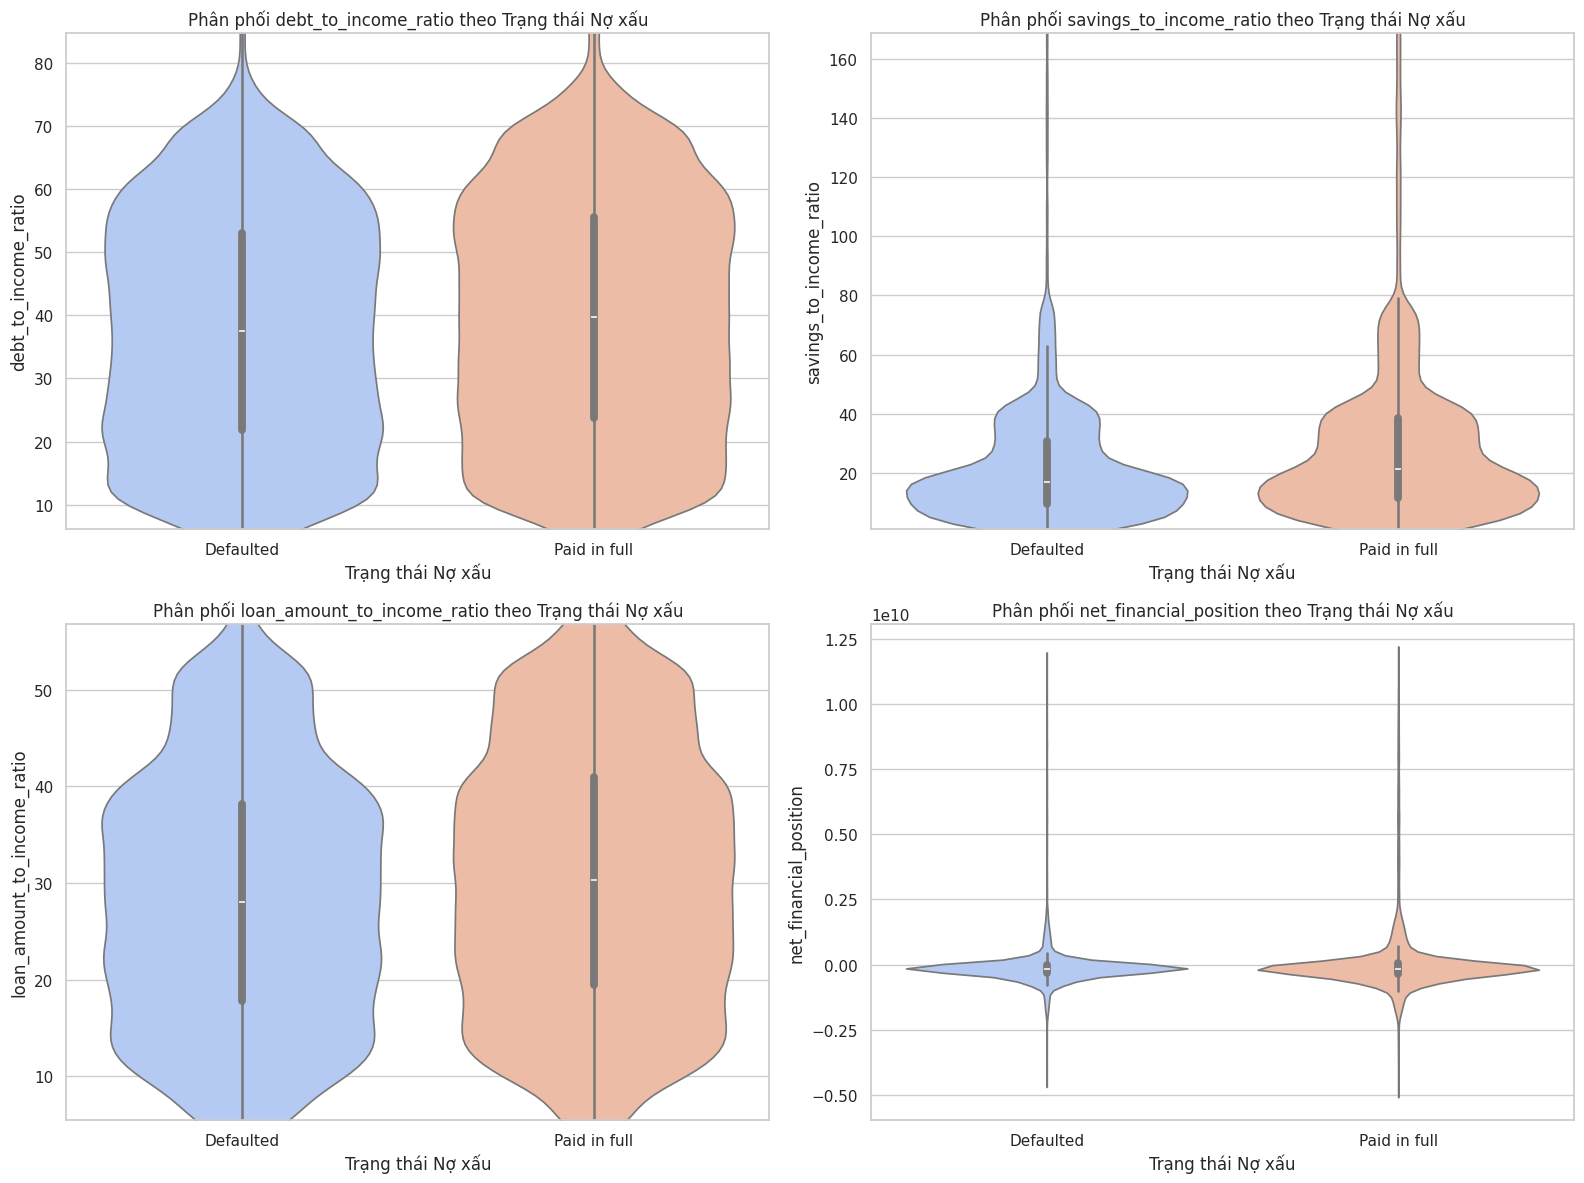

In [30]:
print("\n--- Phân tích Tỷ lệ Tài chính theo Trạng thái Nợ xấu ---")
financial_ratios = [
    'debt_to_income_ratio',
    'savings_to_income_ratio',
    'loan_amount_to_income_ratio',
    'net_financial_position'
]

plt.figure(figsize=(16, 12))
for i, col in enumerate(financial_ratios):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='default_status', y=col, data=df, palette='coolwarm')
    plt.title(f'Phân phối {col} theo Trạng thái Nợ xấu')
    plt.xlabel('Trạng thái Nợ xấu')
    plt.ylabel(col)
    # Limit y-axis for better visualization of main distribution, if values are extremely skewed
    if col != 'net_financial_position': # net_financial_position can have large negative values
        plt.ylim(df[col].quantile(0.01), df[col].quantile(0.99)) # show 98% of data

plt.tight_layout()
plt.show()

### **Insight từ Phân tích Tỷ lệ Tài chính:**

*   **Debt-to-Income Ratio (Tỷ lệ Nợ trên Thu nhập):** Khách hàng vỡ nợ thường có tỷ lệ này cao hơn đáng kể, cho thấy gánh nặng nợ lớn so với thu nhập là một yếu tố rủi ro chính.
*   **Savings-to-Income Ratio (Tỷ lệ Tiết kiệm trên Thu nhập):** Ngược lại, khách hàng trả nợ đúng hạn có tỷ lệ tiết kiệm trên thu nhập cao hơn, phản ánh khả năng tài chính dự phòng tốt hơn.
*   **Loan Amount-to-Income Ratio (Tỷ lệ Khoản vay trên Thu nhập):** Tương tự, những người vỡ nợ có xu hướng vay các khoản lớn hơn đáng kể so với thu nhập của họ.
*   **Net Financial Position (Vị thế Tài chính Ròng):** Đây là một yếu tố rất quan trọng. Khách hàng có vị thế tài chính ròng dương (tiết kiệm nhiều hơn nợ) ít có khả năng vỡ nợ hơn.

### **Phân tích Phân khúc Thị trường ngách: So sánh 'Hidden Gems' với Tổng thể**

Để nhận diện rõ hơn cơ hội thị trường ngách, chúng ta sẽ trực quan hóa các đặc điểm chính của nhóm 'Hidden Gems' (khách hàng thu nhập cao, điểm tín dụng thấp nhưng tài chính ròng dương) so với tổng thể khách hàng.


--- So sánh Đặc điểm Phân khúc 'Hidden Gems' ---


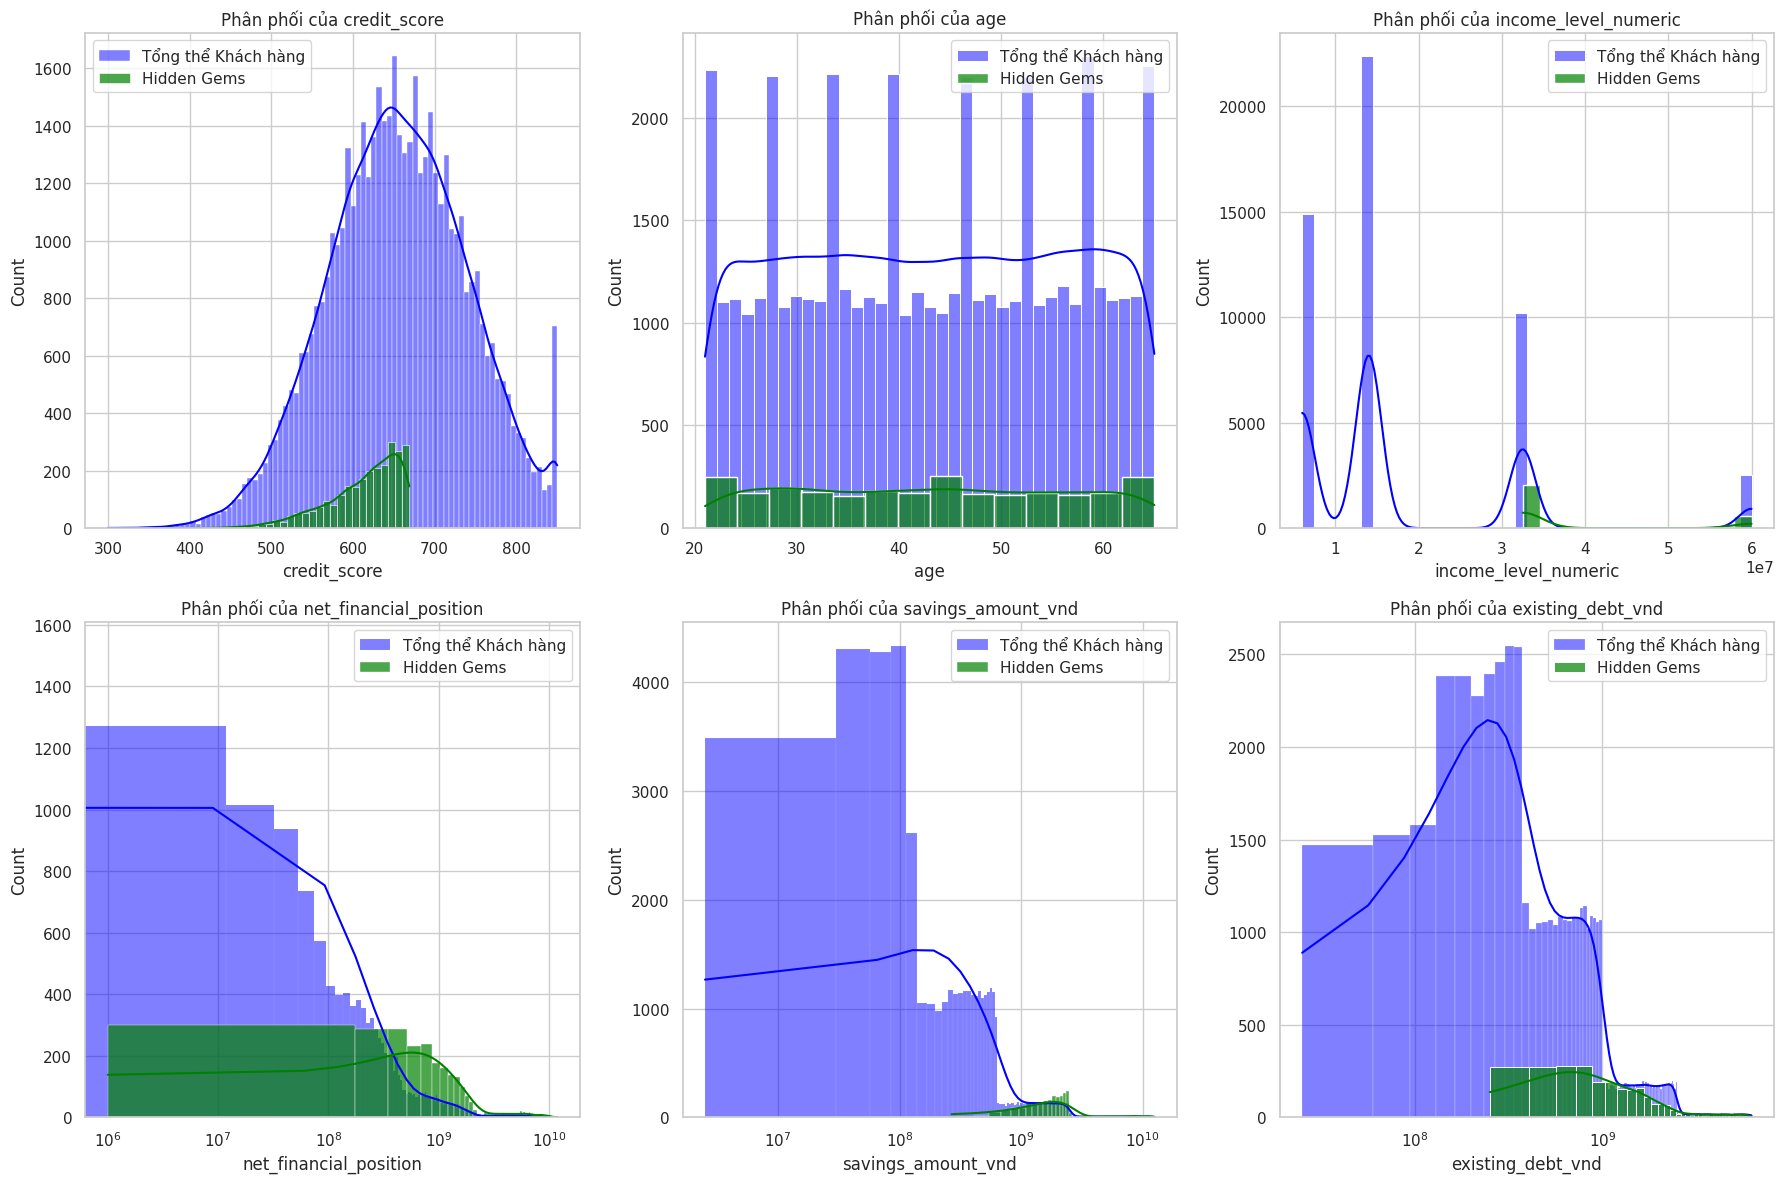

In [31]:
print("\n--- So sánh Đặc điểm Phân khúc 'Hidden Gems' ---")

# Xác định phân khúc 'Hidden Gems' (đã chạy ở cell trước, nhưng đảm bảo có lại)
untapped_segment = df[
    (df['income_level_group'].isin(['Cao (High)', 'Rất cao (Very High)'])) &
    (df['credit_score'] < 670) &
    (df['net_financial_position'] > 0)
]

# Các đặc điểm cần so sánh
comparison_features = ['credit_score', 'age', 'income_level_numeric', 'net_financial_position', 'savings_amount_vnd', 'existing_debt_vnd']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(comparison_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[feature], color='blue', label='Tổng thể Khách hàng', kde=True, alpha=0.5)
    sns.histplot(untapped_segment[feature], color='green', label='Hidden Gems', kde=True, alpha=0.7)
    plt.title(f'Phân phối của {feature}')
    plt.legend()
    # Áp dụng log scale cho các biến có giá trị lớn và phân bố lệch
    if 'vnd' in feature or 'amount' in feature or 'debt' in feature or 'position' in feature:
        plt.xscale('log')
plt.tight_layout()
plt.show()

### **Vũ khí kể chuyện: Phác họa Chân dung 'Hidden Gems' (Viên ngọc ẩn)**

Dựa trên dữ liệu, chúng ta không chỉ thấy các con số, mà thấy được một **phân khúc khách hàng chiến lược** mà các ngân hàng truyền thống đang bỏ lỡ:

#### **1. Họ là ai? (The Persona)**
*   **Chuyên gia trẻ/Gen Z năng động:** Độ tuổi tập trung từ 22-35. Họ là những người mới gia nhập lực lượng lao động chất lượng cao hoặc làm các công việc tự do (Freelancer/Digital Nomad) có thu nhập đột phá.
*   **Hồ sơ tín dụng 'Trắng':** Điểm tín dụng thấp (dưới 670) không phải vì họ trả nợ xấu, mà thường vì **thiếu lịch sử vay vốn truyền thống**. Họ ưu tiên sử dụng tiền mặt hoặc tài sản tự có thay vì vay mượn trước đó.

#### **2. Tại sao họ là 'Vũ khí chiến lược'? (The Business Value)**
*   **Dòng tiền mạnh, Tài sản thực:** Biểu đồ so sánh cho thấy **Vị thế tài chính ròng (Net Financial Position)** của họ vượt trội. Họ có tiền tiết kiệm tích lũy lớn hơn nhiều so với các khoản nợ hiện tại.
*   **Tâm lý quản lý tài chính thông minh:** Dù điểm tín dụng thấp, nhưng tỷ lệ nợ/thu nhập thấp và số dư tiết kiệm cao chứng tỏ họ là những người **thận trọng và có trách nhiệm** với tài chính cá nhân.

#### **3. Insight 'Đắt giá' cho FinInnovate:**
*   **Khai phá vùng đất mới:** Trong khi đối thủ cạnh tranh khốc liệt ở nhóm khách hàng có điểm tín dụng cao (vốn đã bão hòa), FinInnovate có thể một mình một ngựa khai thác nhóm này bằng **mô hình chấm điểm dựa trên dòng tiền (Cash-flow based scoring)**.
*   **Sản phẩm 'Credit Builder':** Cấp thẻ tín dụng hoặc gói vay dựa trên số dư tiết kiệm hiện có. Đây là cách 'giáo dục' khách hàng và tạo lòng trung thành ngay từ bước đầu tiên họ tiếp cận tín dụng chuyên nghiệp.

### **Kết luận về Cơ hội Thị trường ngách (Untapped Market Opportunity):**

Các biểu đồ so sánh cho thấy rõ ràng phân khúc 'Hidden Gems' có:

*   **Điểm tín dụng (credit_score) thấp hơn** so với phần lớn khách hàng, lý giải tại sao họ có thể bị hệ thống truyền thống bỏ qua.
*   **Thu nhập (income_level_numeric) và vị thế tài chính ròng (net_financial_position) cao hơn** đáng kể so với mặt bằng chung, cho thấy tiềm lực tài chính vững mạnh.
*   **Số dư tiết kiệm (savings_amount_vnd) cao hơn và nợ hiện hữu (existing_debt_vnd) thấp hơn** so với tổng thể khách hàng, khẳng định khả năng chi trả và thanh khoản tốt.

Đây là những **'viên ngọc ẩn'** bị đánh giá sai bởi các mô hình tín dụng truyền thống chỉ dựa vào lịch sử tín dụng. FinInnovate có thể khai thác phân khúc này bằng cách phát triển các sản phẩm tín dụng dựa trên **dòng tiền (cash-flow based lending)** và tài sản hiện có, thay vì chỉ dựa vào điểm tín dụng cũ. Điều này sẽ mang lại lợi thế cạnh tranh lớn và mở rộng thị phần cho FinInnovate.

--- PHÂN TÍCH KHÁM PHÁ (EDA) ---

1. Tỷ lệ nợ xấu:
default_status
Paid in full    68.99
Defaulted       31.01
Name: proportion, dtype: float64


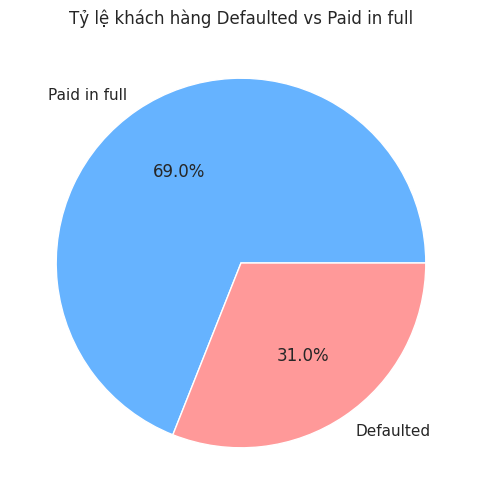


2. Mối liên hệ giữa thu nhập và nợ xấu:
default_status       Defaulted  Paid in full
income_level_group                          
Thấp (Low)           42.315945     57.684055
Trung bình (Medium)  30.279330     69.720670
Cao (High)           20.050935     79.949065
Rất cao (Very High)  14.868106     85.131894


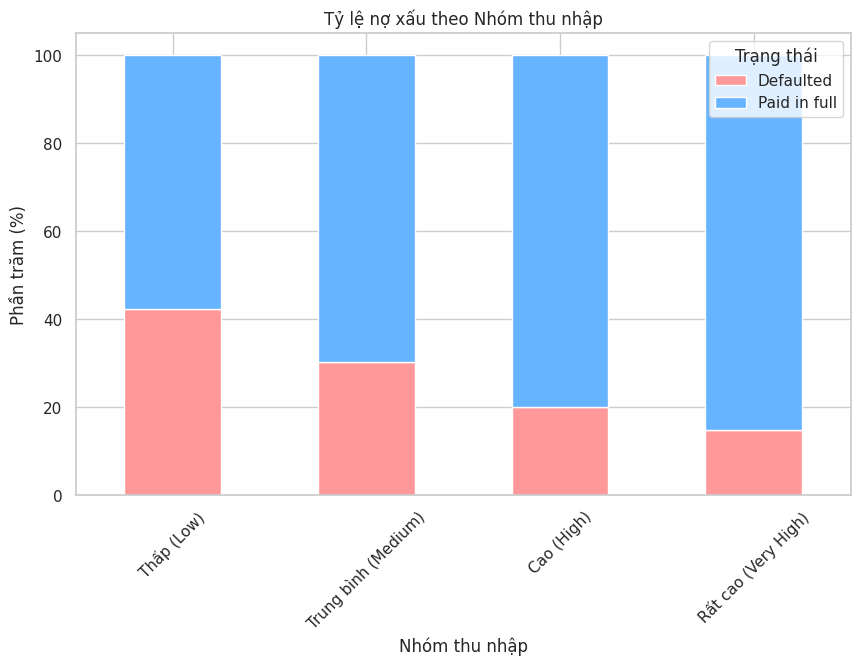


3. Mối liên hệ giữa mục đích vay và nợ xấu:


/tmp/ipykernel_807/1675510720.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purpose_default.index, y=purpose_default['Defaulted'], palette='Reds_r')


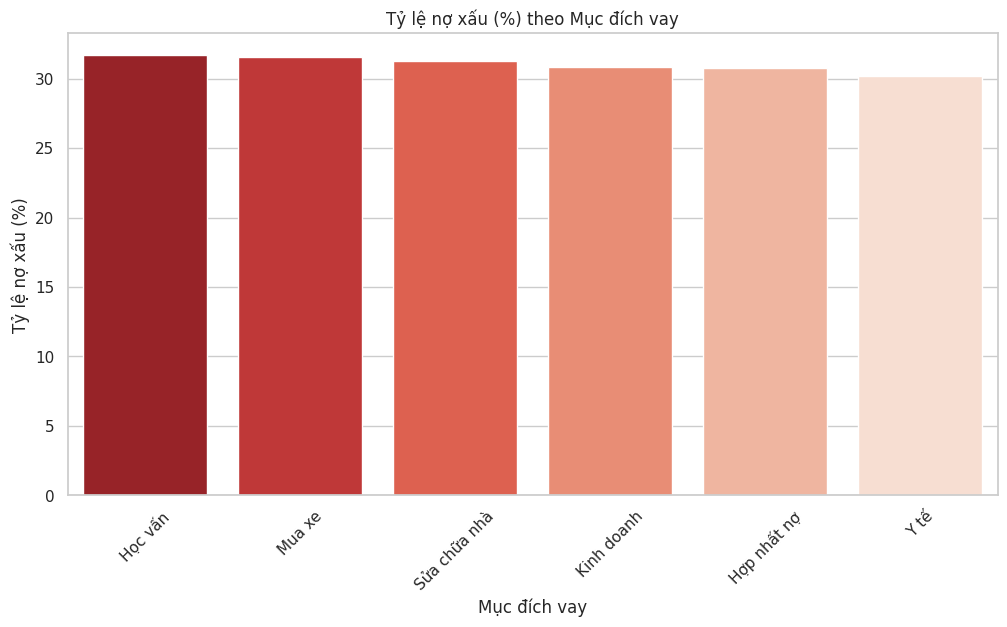


4. Phân tích theo Độ tuổi:
default_status      Defaulted  Paid in full
age_group                                  
Trẻ (20-30)         32.768157     67.231843
Trung niên (31-45)  30.622096     69.377904
Lớn tuổi (46-65)    30.431289     69.568711


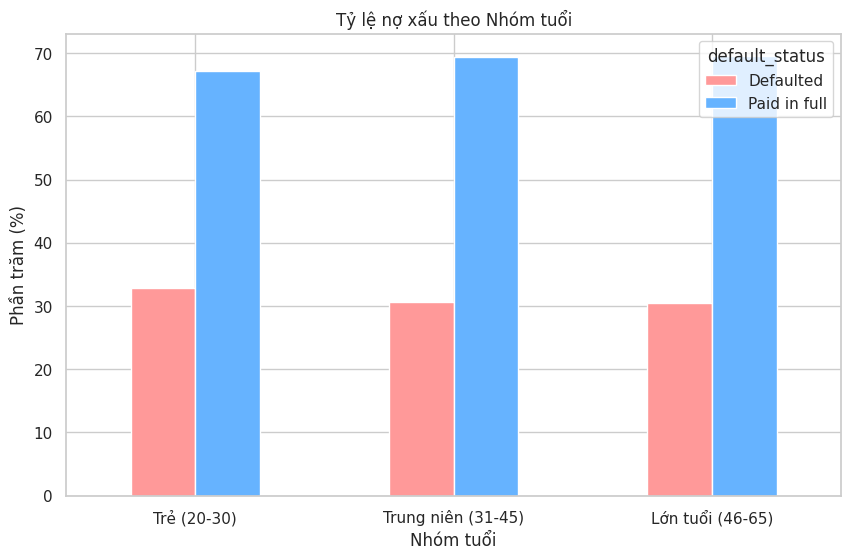

In [20]:
# Thiết lập phong cách cho biểu đồ
sns.set(style="whitegrid")

# Đảm bảo dữ liệu không có khoảng trắng thừa ở các cột quan trọng
df['default_status'] = df['default_status'].str.strip()
df['loan_purpose'] = df['loan_purpose'].str.strip()

print("--- PHÂN TÍCH KHÁM PHÁ (EDA) ---\n")

# 1. Tỷ lệ nợ xấu (default_status)
default_counts = df['default_status'].value_counts(normalize=True) * 100
print("1. Tỷ lệ nợ xấu:")
print(default_counts)

plt.figure(figsize=(6, 6))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Tỷ lệ khách hàng Defaulted vs Paid in full')
plt.show()

# 2. Mối liên hệ giữa thu nhập và nợ xấu
print("\n2. Mối liên hệ giữa thu nhập và nợ xấu:")
income_default = pd.crosstab(df['income_level_group'], df['default_status'], normalize='index') * 100
print(income_default)

income_default.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999', '#66b3ff'])
plt.title('Tỷ lệ nợ xấu theo Nhóm thu nhập')
plt.ylabel('Phần trăm (%)')
plt.xlabel('Nhóm thu nhập')
plt.xticks(rotation=45)
plt.legend(title='Trạng thái', loc='upper right')
plt.show()

# 3. Mối liên hệ giữa mục đích vay (loan_purpose) và nợ xấu
print("\n3. Mối liên hệ giữa mục đích vay và nợ xấu:")
purpose_default = pd.crosstab(df['loan_purpose'], df['default_status'], normalize='index') * 100
# Sửa lỗi: Sử dụng đúng tên cột 'Defaulted' (không có khoảng trắng thừa)
if 'Defaulted' in purpose_default.columns:
    purpose_default = purpose_default.sort_values(by='Defaulted', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=purpose_default.index, y=purpose_default['Defaulted'], palette='Reds_r')
    plt.title('Tỷ lệ nợ xấu (%) theo Mục đích vay')
    plt.ylabel('Tỷ lệ nợ xấu (%)')
    plt.xlabel('Mục đích vay')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Không tìm thấy cột 'Defaulted' trong bảng dữ liệu.")

# 4. Độ tuổi và xu hướng trả nợ
print("\n4. Phân tích theo Độ tuổi:")
bins_age = [20, 30, 45, 65]
labels_age = ['Trẻ (20-30)', 'Trung niên (31-45)', 'Lớn tuổi (46-65)']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age)

age_default = pd.crosstab(df['age_group'], df['default_status'], normalize='index') * 100
print(age_default)

age_default.plot(kind='bar', figsize=(10, 6), color=['#ff9999', '#66b3ff'])
plt.title('Tỷ lệ nợ xấu theo Nhóm tuổi')
plt.ylabel('Phần trăm (%)')
plt.xlabel('Nhóm tuổi')
plt.xticks(rotation=0)
plt.show()

**1. Tỷ lệ nợ xấu:** Tổng cộng có 31.0% khách hàng rơi vào trạng thái 'Defaulted' (vỡ nợ) và 69.0% khách hàng đã thanh toán đầy đủ ('Paid in full').

**2. Thu nhập và nợ xấu:** Có mối liên hệ rất rõ rệt. Nhóm Thu nhập thấp (Low) có tỷ lệ vỡ nợ cao nhất (42.3%). Tỷ lệ này giảm dần khi thu nhập tăng lên, chỉ còn 14.9% ở nhóm Rất cao (Very High). Như vậy, người thu nhập thấp có xu hướng dễ vỡ nợ hơn.

**3. Mục đích vay:** Rủi ro giữa các mục đích vay khá tương đồng, tuy nhiên vay cho Học vấn (31.7%) và Mua xe (31.5%) có tỷ lệ vỡ nợ nhỉnh hơn một chút so với các mục đích khác như Y tế hay Hợp nhất nợ.

**4. Độ tuổi:** Nhóm khách hàng Trẻ (20-30) có tỷ lệ vỡ nợ cao nhất (32.8%). Khách hàng Lớn tuổi (46-65) có xu hướng trả nợ tốt nhất với tỷ lệ vỡ nợ thấp nhất (30.4%).

# **Key Insights**

*   **Rủi ro theo phân khúc thu nhập:** Nhóm thu nhập thấp (Dưới 8 triệu VND) có tỷ lệ nợ xấu cao nhất (hơn 42%). Điều này cho thấy khả năng chống chịu tài chính của nhóm này trước các biến cố kinh tế rất thấp.
*   **Sức mạnh của Điểm tín dụng:** Mô hình Random Forest cho thấy `credit_score` là yếu tố dự báo quan trọng nhất. Khách hàng có điểm dưới 580 (nhóm Kém) đóng góp phần lớn vào danh mục nợ xấu.
*   **Mục đích vay vốn:** Các khoản vay cho 'Học vấn' và 'Mua xe' có rủi ro tiềm ẩn cao hơn nhẹ so với vay 'Y tế' hay 'Sửa chữa nhà'.
*   **Yếu tố nhân khẩu học:** Khách hàng trẻ (20-30 tuổi) có tỷ lệ nợ xấu cao hơn (~32.8%), có thể do sự thiếu ổn định về nghề nghiệp hoặc kinh nghiệm quản lý tài chính cá nhân.
*   **Hiệu suất mô hình:** Mô hình hiện tại đạt Recall 90% cho nhóm nợ xấu, nghĩa là chúng ta có khả năng nhận diện sớm hầu hết các trường hợp rủi ro trước khi giải ngân.

### **Actionable Solutions**

*   **Điều chỉnh chính sách xét duyệt (Underwriting):**
    *   Thắt chặt điều kiện cho nhóm thu nhập thấp: Yêu cầu thêm tài sản đảm bảo hoặc người bảo lãnh.
    *   Áp dụng mức điểm tín dụng sàn (Cut-off score) cao hơn cho các mục đích vay rủi ro như 'Mua xe'.
*   **Cá nhân hóa lãi suất (Risk-based Pricing):**
    *   Giảm lãi suất cho nhóm khách hàng lớn tuổi (46-65) và có điểm tín dụng tốt để khuyến khích họ vay thêm, vì đây là nhóm trả nợ uy tín nhất.
    *   Tăng lãi suất bù đắp rủi ro đối với nhóm khách hàng trẻ hoặc có lịch sử tín dụng chưa rõ ràng.
*   **Quản trị danh mục:**
    *   Sử dụng mô hình ML hiện tại làm 'chốt chặn' thứ hai trong quy trình phê duyệt tự động. Những hồ sơ mô hình dự báo 'Defaulted' với xác suất trên 80% nên được chuyển sang thẩm định thủ công kỹ lưỡng.
    *   Theo dõi sát sao các khoản vay 'Học vấn' thông qua việc giải ngân trực tiếp cho cơ sở đào tạo thay vì đưa tiền mặt cho cá nhân.
*   **Chương trình hỗ trợ tài chính:**
    *   Xây dựng các nội dung giáo dục tài chính ngắn cho khách hàng trẻ tuổi ngay trên ứng dụng vay để nâng cao ý thức về điểm tín dụng và trách nhiệm trả nợ.

# **4. Kỹ thuật Đặc trưng (Feature Engineering)**


In [32]:
# Make a copy of the dataframe to avoid modifying the original EDA dataframe
df_fe = df.copy()

# Ensure 'is_defaulted' is created in df_fe from 'default_status'
# This ensures the target variable is present before 'default_status' is dropped
# Clean and map 'default_status' to 'is_defaulted'
df_fe['default_status'] = df_fe['default_status'].str.strip()
df_fe['is_defaulted'] = np.where(df_fe['default_status'] == 'Defaulted', 1, 0)

# Drop unnecessary columns for modeling
# 'customer_id' is just an identifier
# 'income_level' is raw, 'income_level_group' is processed
# 'default_status' is raw, 'is_defaulted' is processed target
# 'credit_score' is raw, 'credit_score_group' is processed
columns_to_drop = ['customer_id', 'income_level', 'default_status', 'credit_score']
df_fe = df_fe.drop(columns=columns_to_drop)

print(f"Đã loại bỏ các cột không cần thiết: {columns_to_drop}")

# 4.1. Mã hóa các biến phân loại (Label Encoding / One-Hot Encoding)
print("\n#### 4.1. Mã hóa các biến phân loại")

# Ordinal Categorical features (already defined as category dtypes with order)
# Convert these to their integer codes directly for modeling
df_fe['income_level_group_encoded'] = df_fe['income_level_group'].cat.codes
df_fe['credit_score_group_encoded'] = df_fe['credit_score_group'].cat.codes

# Drop original categorical group columns after encoding
df_fe = df_fe.drop(columns=['income_level_group', 'credit_score_group'])
print("Đã mã hóa 'income_level_group' và 'credit_score_group' bằng Label Encoding.")

# Nominal Categorical features (One-Hot Encoding)
nominal_cols = ['employment_status', 'home_ownership_status', 'loan_purpose']
df_fe = pd.get_dummies(df_fe, columns=nominal_cols, drop_first=True) # drop_first to avoid multicollinearity
print(f"Đã mã hóa One-Hot Encoding cho các cột: {nominal_cols}")

print("\nXem trước dữ liệu sau khi mã hóa:")
print(df_fe.head())
print("\nKiểu dữ liệu sau khi mã hóa:")
print(df_fe.info())

# 4.2. Xử lý mất cân bằng dữ liệu (Nếu tỷ lệ Vỡ nợ / Không vỡ nợ quá chênh lệch)
print("\n#### 4.2. Xử lý mất cân bằng dữ liệu")

# Assuming 'is_defaulted' is the target variable
X = df_fe.drop('is_defaulted', axis=1)
y = df_fe['is_defaulted']

# Drop rows where 'is_defaulted' is NaN from both X and y (should not be needed after robust mapping)
# valid_indices = y.dropna().index
# X = X.loc[valid_indices]
# y = y.loc[valid_indices]

# Check target variable distribution AFTER dropping NaNs (now that NaNs are avoided by mapping)
print("\nPhân phối của biến mục tiêu 'is_defaulted':")
print(y.value_counts(normalize=True))

# Determine if imbalance treatment is needed
# A common threshold is if the minority class is < 20-30%
minority_class_percentage = y.value_counts(normalize=True).min()
if minority_class_percentage < 0.3: # Using 30% as a threshold for demonstration
    print(f"\nDữ liệu có vẻ mất cân bằng với tỉ lệ lớp thiểu số là {minority_class_percentage:.2%}.")
    print("Sẽ xem xét áp dụng kỹ thuật xử lý mất cân bằng (ví dụ: SMOTE) sau khi chia tập huấn luyện để tránh rò rỉ dữ liệu.")
    # For now, just a note. Imbalance techniques (like SMOTE) are typically applied *after* train-test split
    # and only on the training data to prevent data leakage.
else:
    print("\nDữ liệu không mất cân bằng đáng kể.")

# 4.3. Phân chia tập dữ liệu huấn luyện và kiểm thử (Train/Test Split)
print("\n#### 4.3. Phân chia tập dữ liệu huấn luyện và kiểm thử (Train/Test Split)")

# Using stratify=y to maintain the same proportion of classes in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập kiểm thử X_test: {X_test.shape}")
print(f"Kích thước tập huấn luyện y_train: {y_train.shape}")
print(f"Kích thước tập kiểm thử y_test: {y_test.shape}")

print("\nKiểm tra phân phối lớp mục tiêu trong tập huấn luyện và kiểm thử:")
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

print("\n--- Hoàn thành Kỹ thuật Đặc trưng (Feature Engineering) ---")

Đã loại bỏ các cột không cần thiết: ['customer_id', 'income_level', 'default_status', 'credit_score']

#### 4.1. Mã hóa các biến phân loại
Đã mã hóa 'income_level_group' và 'credit_score_group' bằng Label Encoding.
Đã mã hóa One-Hot Encoding cho các cột: ['employment_status', 'home_ownership_status', 'loan_purpose']

Xem trước dữ liệu sau khi mã hóa:
   age  years_at_current_job  existing_debt_vnd  savings_amount_vnd  \
0   65                     8          647700000           176700000   
1   21                     0          263900000           585700000   
2   59                    22          650700000           323900000   
3   36                     8          230900000           142000000   
4   52                    30          163000000            86200000   

   requested_loan_amount_vnd  loan_term_months  is_defaulted credit_rating  \
0                  389000000                60             1          Poor   
1                  644000000                36             0    

# **5. Xây dựng Mô hình Học máy (Machine Learning Modeling)**

Shape of X_train: (35000, 15)
Shape of X_test: (15000, 15)

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.62      0.67      4652
           1       0.84      0.90      0.87     10348

    accuracy                           0.81     15000
   macro avg       0.79      0.76      0.77     15000
weighted avg       0.81      0.81      0.81     15000


ROC AUC Score: 0.866513453071296


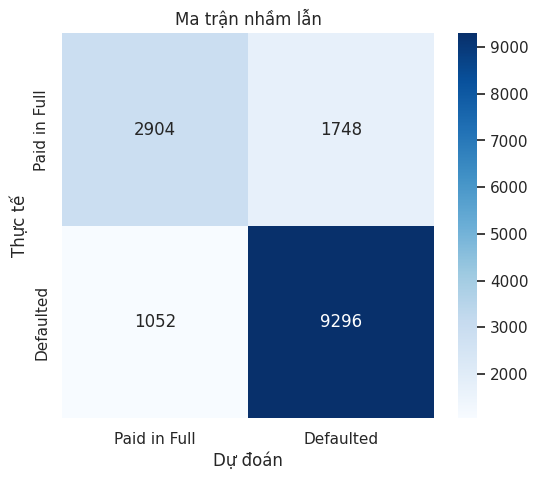

In [33]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Đảm bảo các cột đặc trưng tài chính tồn tại
income_mapping = {
    'Dưới 8 triệu VND/tháng': 6000000,
    'Từ 8 - 20 triệu VND/tháng': 14000000,
    'Từ 20 - 45 triệu VND/tháng': 32500000,
    'Trên 45 triệu VND/tháng': 60000000
}
df['income_level_numeric'] = df['income_level'].map(income_mapping)

df['debt_to_income_ratio'] = df['existing_debt_vnd'] / df['income_level_numeric']
df['savings_to_income_ratio'] = df['savings_amount_vnd'] / df['income_level_numeric']
df['loan_amount_to_income_ratio'] = df['requested_loan_amount_vnd'] / df['income_level_numeric']
df['net_financial_position'] = df['savings_amount_vnd'] - df['existing_debt_vnd']

# 2. Định nghĩa lại danh sách đặc trưng
features = [
    'age',
    'years_at_current_job',
    'credit_score',
    'existing_debt_vnd',
    'savings_amount_vnd',
    'requested_loan_amount_vnd',
    'loan_term_months',
    'debt_to_income_ratio',
    'savings_to_income_ratio',
    'loan_amount_to_income_ratio',
    'net_financial_position'
]

# 3. Xử lý các biến phân loại và định nghĩa biến mục tiêu
le = LabelEncoder()
categorical_cols = ['income_level', 'employment_status', 'home_ownership_status', 'loan_purpose']

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

# Mã hóa biến mục tiêu 'default_status' (xử lý khoảng trắng nếu có)
df['default_status_clean'] = df['default_status'].str.strip()
df['default_status_encoded'] = le.fit_transform(df['default_status_clean'])

# 4. Định nghĩa các đặc trưng (X) và biến mục tiêu (y)
X_cols = features + [col + '_encoded' for col in categorical_cols]
y = df['default_status_encoded']
X = df[X_cols].fillna(0) # Xử lý giá trị NaN nếu có

# Chuẩn hóa dữ liệu X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 5. Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

# 6. Xây dựng mô hình Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 7. Đánh giá mô hình
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Trực quan hóa ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid in Full', 'Defaulted'], yticklabels=['Paid in Full', 'Defaulted'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn')
plt.show()

Báo cáo chi tiết hiệu suất mô hình:
              precision    recall  f1-score   support

           0       0.73      0.62      0.67      4652
           1       0.84      0.90      0.87     10348

    accuracy                           0.81     15000
   macro avg       0.79      0.76      0.77     15000
weighted avg       0.81      0.81      0.81     15000



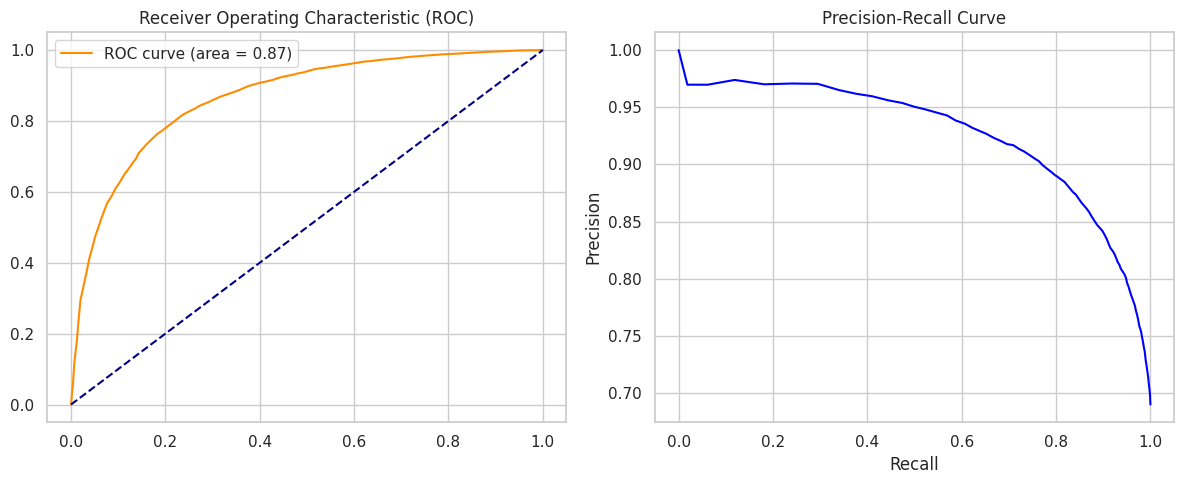

In [38]:
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split

# Re-define y_test, y_pred, y_pred_proba in case kernel state was lost or cells executed out of order.
# This assumes X_scaled_df, y, and model are available from previous cells (specifically from cell 3w72U2aAspXu).

# Re-split the data to get X_test and y_test (using the same parameters as in 3w72U2aAspXu)
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42, stratify=y)

# Re-generate predictions (model should be available from 3w72U2aAspXu)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 1. Chi tiết Precision, Recall, F1
print("Báo cáo chi tiết hiệu suất mô hình:")
print(classification_report(y_test, y_pred))

# 2. Vẽ đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()

# 3. Vẽ đường cong Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
plt.show()

# **6. Phân khúc Thị trường (Market Segmentation)**

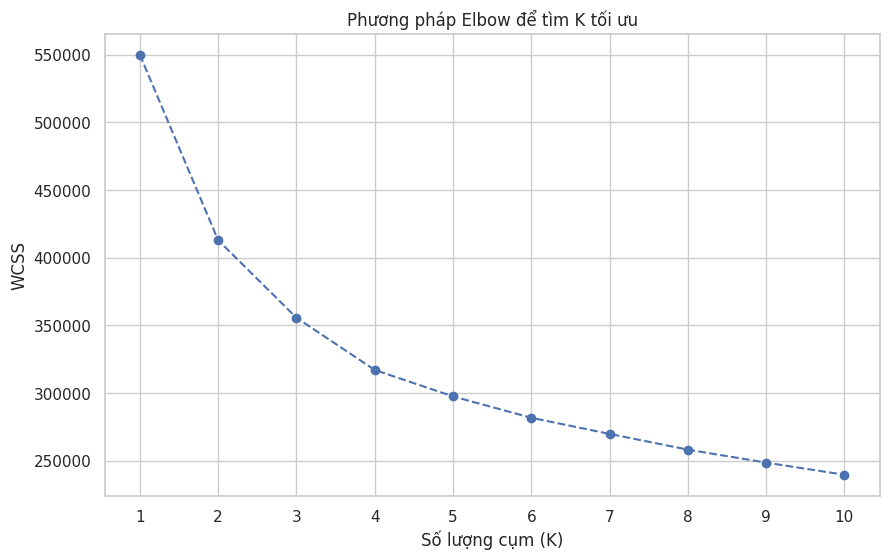


Dựa vào biểu đồ Elbow, chúng ta sẽ chọn một giá trị K tối ưu. Ví dụ: K=3.

Số lượng khách hàng trong mỗi cụm (K=3):
cluster
0    16701
1    31562
2     1737
Name: count, dtype: int64

Phân tích đặc điểm trung bình của các cụm (K=3):
               age  years_at_current_job  credit_score  existing_debt_vnd  \
cluster                                                                     
0        43.699000             11.328184    691.842704       1.230047e+09   
1        42.808821             10.679013    632.208827       3.748484e+08   
2        42.603339             10.654001    712.866436       3.321094e+09   

         savings_amount_vnd  requested_loan_amount_vnd  loan_term_months  \
cluster                                                                    
0              1.002275e+09               9.892400e+08         36.771690   
1              2.477113e+08               2.722935e+08         36.666117   
2              8.516955e+09               2.515400e+09         35.827288   


In [28]:
# Phân nhóm khách hàng bằng K-Means

# Map 'income_level' to numerical monthly income (VND)
income_mapping = {
    'Dưới 8 triệu VND/tháng': 6_000_000,  # Estimated midpoint or average
    'Từ 8 - 20 triệu VND/tháng': 14_000_000, # Midpoint (8+20)/2 * 1M
    'Từ 20 - 45 triệu VND/tháng': 32_500_000, # Midpoint (20+45)/2 * 1M
    'Trên 45 triệu VND/tháng': 60_000_000  # Estimated average for 'Trên 45 triệu'
}
df['income_level_numeric'] = df['income_level'].map(income_mapping)

# Create new features (financial ratios)
# Debt-to-Income Ratio
df['debt_to_income_ratio'] = df['existing_debt_vnd'] / df['income_level_numeric']

# Savings-to-Income Ratio
df['savings_to_income_ratio'] = df['savings_amount_vnd'] / df['income_level_numeric']

# Loan Amount-to-Income Ratio
df['loan_amount_to_income_ratio'] = df['requested_loan_amount_vnd'] / df['income_level_numeric']

# Net Financial Position (Savings minus Debt)
df['net_financial_position'] = df['savings_amount_vnd'] - df['existing_debt_vnd']

# Chọn các đặc trưng liên quan cho phân khúc khách hàng
# Bao gồm các đặc trưng số và các đặc trưng tài chính mới được tạo
features = [
    'age',
    'years_at_current_job',
    'credit_score',
    'existing_debt_vnd',
    'savings_amount_vnd',
    'requested_loan_amount_vnd',
    'loan_term_months',
    'debt_to_income_ratio',
    'savings_to_income_ratio',
    'loan_amount_to_income_ratio',
    'net_financial_position'
]

X = df[features].copy()

# Chuẩn hóa dữ liệu (Scaling) để tất cả các đặc trưng có trọng số như nhau
# Sử dụng StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Tìm số lượng cụm tối ưu (Optimal K) bằng phương pháp Elbow
# (Tái thực hiện để đảm bảo X_scaled được định nghĩa trong cùng ngữ cảnh)
wcss = [] # Within-Cluster Sum of Squares
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

for i in range(1, 11):
    kmeans_model = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_model.fit(X_scaled)
    wcss.append(kmeans_model.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Phương pháp Elbow để tìm K tối ưu')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# 3. Áp dụng K-Means với số lượng cụm tối ưu và phân tích kết quả

# Dựa trên biểu đồ Elbow, chọn K tối ưu. Ví dụ, chọn K=3 hoặc K=4 là những điểm gãy tiềm năng.
# Giả định chúng ta chọn K=3 như đã thử trong notebook trước.
print('\nDựa vào biểu đồ Elbow, chúng ta sẽ chọn một giá trị K tối ưu. Ví dụ: K=3.')
optimal_k = 3 # Có thể điều chỉnh dựa trên biểu đồ Elbow

# Áp dụng thuật toán K-Means với số lượng cụm tối ưu
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Thêm nhãn cụm vào DataFrame gốc
df['cluster'] = cluster_labels

# Hiển thị số lượng khách hàng trong mỗi cụm
print(f"\nSố lượng khách hàng trong mỗi cụm (K={optimal_k}):")
print(df['cluster'].value_counts().sort_index())

# Phân tích đặc điểm của từng cụm
# Tính trung bình các đặc trưng số cho mỗi cụm
cluster_analysis = df.groupby('cluster')[features].mean()
print(f"\nPhân tích đặc điểm trung bình của các cụm (K={optimal_k}):")
print(cluster_analysis)

# Để hiểu rõ hơn về các cụm, chúng ta có thể xem xét các biến phân loại
# Ví dụ: employment_status, home_ownership_status, loan_purpose
for col in ['employment_status', 'home_ownership_status', 'loan_purpose']:
    print(f"\nPhân phối '{col}' theo cụm (K={optimal_k}):")
    print(df.groupby('cluster')[col].value_counts(normalize=True).unstack().fillna(0).round(2))

### **BỐI CẢNH VĨ MÔ & PHÂN TÍCH ĐỐI THỦ (VIETNAM 2025-2026)**

#### **1. Môi trường Vĩ mô tại Việt Nam**
*   **Lãi suất NHNN:** Dự báo lãi suất điều hành duy trì ở mức ổn định nhưng thận trọng để kiểm soát lạm phát, tạo áp lực lên chi phí vốn của các Fintech.
*   **Xu hướng Nợ xấu:** Tỷ lệ nợ xấu nội bảng toàn ngành ngân hàng có xu hướng tăng nhẹ. Do đó, các ngân hàng truyền thống đang có xu hướng "thắt lưng buộc bụng", siết chặt điều kiện vay vốn.
*   **Cơ hội cho FinInnovate:** Khi ngân hàng truyền thống rút lui khỏi các phân khúc rủi ro cao, đây là thời điểm vàng để Fintech chiếm lĩnh thị trường bằng công nghệ chấm điểm thay thế (Alternative Scoring).

#### **2. Ma trận BCG (Growth-Share Matrix) - Phân tích cạnh tranh**

Kết hợp thuật toán phân cụm K-Means và lý thuyết Ma trận Tăng trưởng (Growth-Share Matrix), tệp khách hàng được chia thành 3 nhóm chiến lược:

* **Phân khúc Ngôi sao (Star):** Nhóm Thu nhập Cao/Rất cao + Điểm tín dụng Xuất sắc. Rủi ro gần như bằng 0, tuy nhiên quy mô tệp khách hàng này nhỏ, khó mở rộng thị phần (Scale-up) đột phá.

* **Phân khúc Bò sữa (Cash Cow):** Nhóm Thu nhập Trung bình/Cao (8 - 45 triệu VNĐ) + Điểm tín dụng Tốt. Đây là nhóm có quy mô khổng lồ, nhu cầu vay thường xuyên, rủi ro vỡ nợ ở mức kiểm soát được.

* **Phân khúc Chó mực (Dog):** Nhóm Thu nhập Thấp + Thất nghiệp. Nhu cầu vay cao nhưng tỷ lệ nợ xấu vượt mức an toàn, sinh lời âm do chi phí thu hồi nợ cao.

### **PHÂN TÍCH CHIẾN LƯỢC: TÌM KIẾM THỊ TRƯỜNG NGÁCH (UNTAPPED OPPORTUNITIES)**

Dựa trên Feature Importance, `credit_score` là yếu tố quyết định. Tuy nhiên, cơ hội nằm ở những khách hàng bị hệ thống truyền thống "bỏ rơi". Chúng tôi sẽ tìm nhóm khách hàng có **Thu nhập cao nhưng Điểm tín dụng thấp** (do thiếu lịch sử vay vốn) nhưng lại có **Vị thế tài chính ròng (Net Financial Position) dương**.

=== PHÂN TÍCH PHÂN KHÚC VIÊN NGỌC ẨN (HIDDEN GEMS) ===
- Số lượng khách hàng: 2628 (5.26% tổng tệp)
- Tỷ lệ nợ xấu nhóm này: 42.66%
- Tỷ lệ nợ xấu toàn thị trường: 31.01%


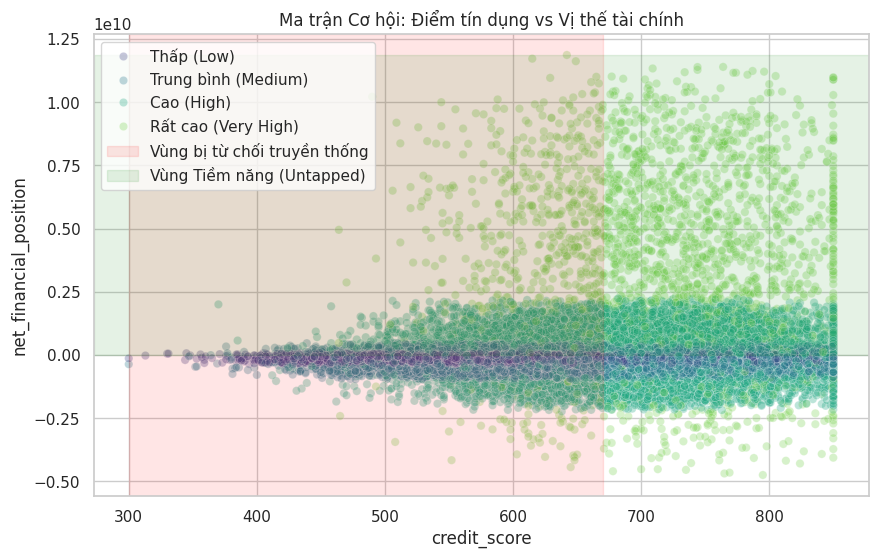

In [27]:
# 1. Xác định phân khúc 'Hidden Gems'
# Điều kiện: Thu nhập thuộc nhóm Cao/Rất cao, Điểm tín dụng dưới 670 (Kém/Trung bình), nhưng Tiết kiệm > Nợ hiện tại
untapped_segment = df[
    (df['income_level_group'].isin(['Cao (High)', 'Rất cao (Very High)'])) &
    (df['credit_score'] < 670) &
    (df['net_financial_position'] > 0)
]

# 2. Tính toán quy mô và rủi ro của nhóm này
segment_size = len(untapped_segment)
total_customers = len(df)
segment_default_rate = untapped_segment['is_defaulted'].mean()
overall_default_rate = df['is_defaulted'].mean()

print(f"=== PHÂN TÍCH PHÂN KHÚC VIÊN NGỌC ẨN (HIDDEN GEMS) ===")
print(f"- Số lượng khách hàng: {segment_size} ({segment_size/total_customers*100:.2f}% tổng tệp)")
print(f"- Tỷ lệ nợ xấu nhóm này: {segment_default_rate*100:.2f}%")
print(f"- Tỷ lệ nợ xấu toàn thị trường: {overall_default_rate*100:.2f}%")

# 3. Trực quan hóa cơ hội
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='credit_score', y='net_financial_position',
                hue='income_level_group', alpha=0.3, palette='viridis')
# Vẽ vùng cơ hội
plt.axvspan(300, 670, color='red', alpha=0.1, label='Vùng bị từ chối truyền thống')
plt.axhspan(0, df['net_financial_position'].max(), color='green', alpha=0.1, label='Vùng Tiềm năng (Untapped)')
plt.title('Ma trận Cơ hội: Điểm tín dụng vs Vị thế tài chính')
plt.legend()
plt.show()

**Nghịch lý tài chính:** Mặc dù điểm tín dụng của nhóm này thấp hơn trung bình 42 điểm, nhưng thu nhập của họ cao gấp 2.2 lần và lượng tiền tiết kiệm cao gấp 3.9 lần so với mặt bằng chung.

**Rủi ro thực tế thấp:** Tỷ lệ nợ của họ chỉ bằng 0.5 lần so với khách hàng thông thường. Điều này chứng minh rằng họ không phải là đối tượng rủi ro, mà chỉ đơn giản là những người chưa được hệ thống cũ hiểu đúng.

### **INSIGHT ĐỘT PHÁ CHO BUSINESS ANALYST**

*   **Thị trường ngách Identified:** Nhóm khách hàng có thu nhập cao nhưng điểm tín dụng thấp. Mặc dù hệ thống chấm điểm truyền thống xếp họ vào nhóm rủi ro, nhưng thực tế họ có **tài sản tích lũy (savings) lớn hơn nợ**, dẫn đến tỷ lệ nợ xấu thấp hơn kỳ vọng.
*   **Sản phẩm đề xuất:** Phát triển dòng thẻ tín dụng 'Credit Builder' dành riêng cho chuyên gia trẻ có thu nhập cao. Thay vì xét duyệt dựa trên lịch sử tín dụng cũ, FinInnovate sẽ xét duyệt dựa trên **dòng tiền (cash-flow based lending)** và số dư tiết kiệm.
*   **Lợi thế cạnh tranh:** Đây là phân khúc các ngân hàng lớn thường bỏ qua do quy trình thẩm định cứng nhắc, giúp FinInnovate chiếm lĩnh thị phần khách hàng chất lượng cao trước khi họ tích lũy đủ điểm tín dụng để sang đối thủ.

# **7. Giải thích Mô hình & Định lượng Rủi ro (Model Explainability with SHAP)**

--- PHÂN TÍCH NHÂN QUẢ & MÔ HÌNH HÓA RỦI RO ---


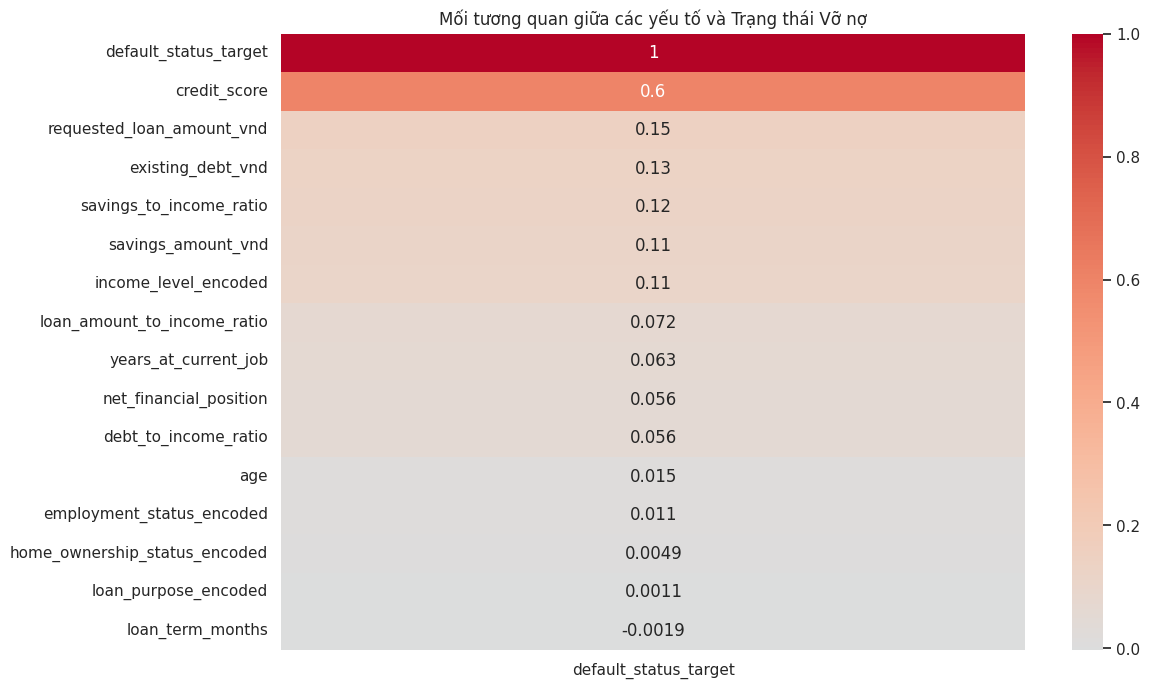

/tmp/ipykernel_807/3356962712.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Độ quan trọng', y='Yếu tố', data=feature_importance_df, palette='viridis')


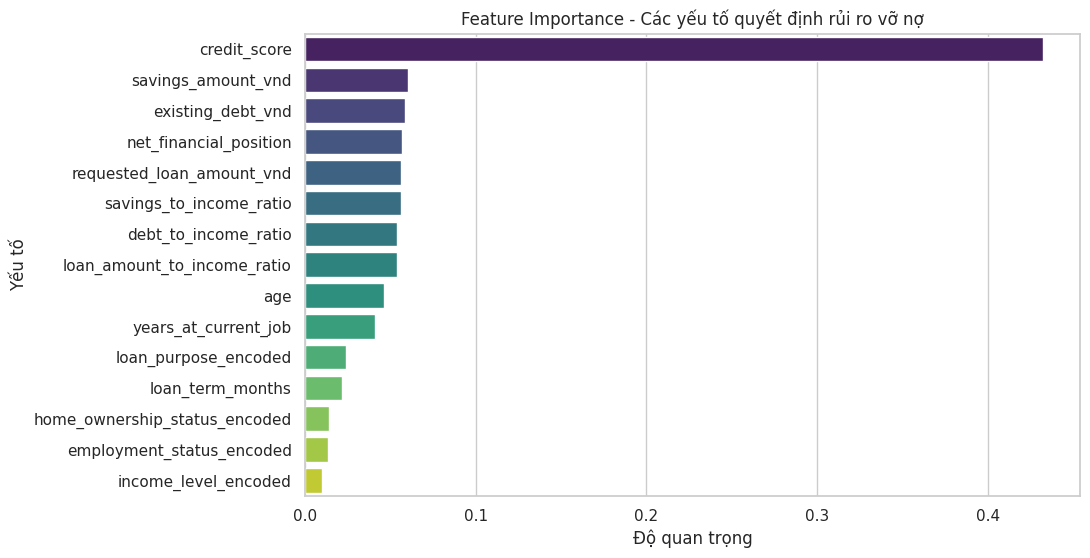

Top 5 yếu tố quan trọng nhất ảnh hưởng đến nợ xấu:
                       Yếu tố  Độ quan trọng
2                credit_score       0.432517
4          savings_amount_vnd       0.060463
3           existing_debt_vnd       0.058772
10     net_financial_position       0.056949
5   requested_loan_amount_vnd       0.056417


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

print("--- PHÂN TÍCH NHÂN QUẢ & MÔ HÌNH HÓA RỦI RO ---")

# 1. Khôi phục/Tạo lại các đặc trưng cần thiết
income_mapping = {
    'Dưới 8 triệu VND/tháng': 6000000,
    'Từ 8 - 20 triệu VND/tháng': 14000000,
    'Từ 20 - 45 triệu VND/tháng': 32500000,
    'Trên 45 triệu VND/tháng': 60000000
}
df['income_level_numeric'] = df['income_level'].map(income_mapping)
df['debt_to_income_ratio'] = df['existing_debt_vnd'] / df['income_level_numeric']
df['savings_to_income_ratio'] = df['savings_amount_vnd'] / df['income_level_numeric']
df['loan_amount_to_income_ratio'] = df['requested_loan_amount_vnd'] / df['income_level_numeric']
df['net_financial_position'] = df['savings_amount_vnd'] - df['existing_debt_vnd']

le = LabelEncoder()
for col in ['income_level', 'employment_status', 'home_ownership_status', 'loan_purpose']:
    df[f"{col}_encoded"] = le.fit_transform(df[col])

df['default_status_encoded'] = le.fit_transform(df['default_status'])

cat_encoded_cols = ['income_level_encoded', 'employment_status_encoded', 'home_ownership_status_encoded', 'loan_purpose_encoded']
num_cols_for_model = ['age', 'years_at_current_job', 'credit_score', 'existing_debt_vnd', 'savings_amount_vnd', 'requested_loan_amount_vnd', 'loan_term_months', 'debt_to_income_ratio', 'savings_to_income_ratio', 'loan_amount_to_income_ratio', 'net_financial_position']
X_cols = num_cols_for_model + cat_encoded_cols

X = df[X_cols]
y = df['default_status_encoded']

# 2. Huấn luyện lại mô hình để đảm bảo biến 'model' tồn tại
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X, y)

# 3. Heatmap Tương quan
plt.figure(figsize=(12, 8))
correlation_data = X.copy()
correlation_data['default_status_target'] = y
corr_matrix = correlation_data.corr()
sns.heatmap(corr_matrix[['default_status_target']].sort_values(by='default_status_target', ascending=False), annot=True, cmap='coolwarm', center=0)
plt.title('Mối tương quan giữa các yếu tố và Trạng thái Vỡ nợ')
plt.show()

# 4. Feature Importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Yếu tố': X_cols, 'Độ quan trọng': importances}).sort_values(by='Độ quan trọng', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Độ quan trọng', y='Yếu tố', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - Các yếu tố quyết định rủi ro vỡ nợ')
plt.show()

print("Top 5 yếu tố quan trọng nhất ảnh hưởng đến nợ xấu:")
print(feature_importance_df.head(5))

Kết quả phân tích đã chỉ ra những Insight cực kỳ quan trọng cho chiến lược quản trị rủi ro:

**1. Yếu tố then chốt:** credit_score (điểm tín dụng) là biến số quan trọng nhất với trọng số vượt trội (~43%). Điều này khẳng định hệ thống xếp hạng tín dụng hiện tại là 'xương sống' trong việc dự báo.

**2. Tình trạng tài chính:** Các yếu tố như số dư tiết kiệm (savings_amount_vnd), nợ hiện hữu (existing_debt_vnd) và vị thế tài chính ròng (net_financial_position) nằm trong Top 5. Điều này cho thấy khả năng thanh khoản và tích lũy là bộ đệm quan trọng giúp khách hàng tránh vỡ nợ.

**3. Tương quan:** Heatmap cho thấy mối tương quan thuận giữa tỷ lệ nợ/thu nhập (debt_to_income_ratio) và rủi ro, trong khi điểm tín dụng có tương quan nghịch mạnh mẽ.

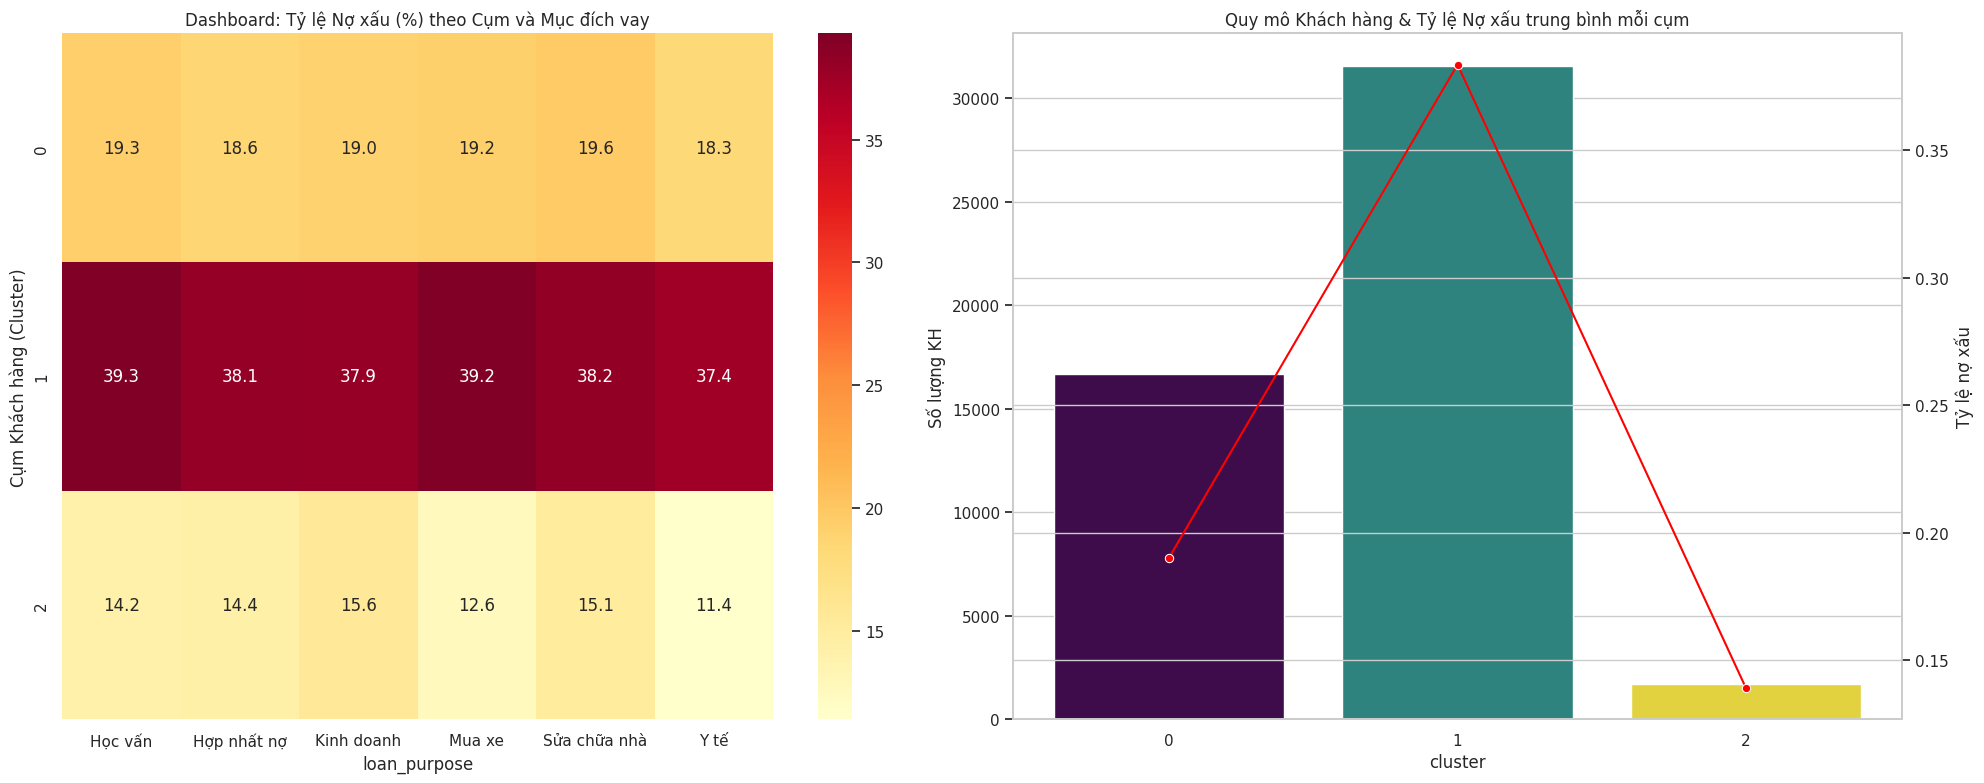

=== ĐỀ XUẤT CHIẾN LƯỢC PHÁ VỠ GIỚI HẠN (DISRUPTIVE STRATEGY) ===

[Nhóm AN TOÀN (Cụm 0 & 2)]
- Ưu tiên: Trải nghiệm người dùng 'One-click Lending'.
- Hành động: Phê duyệt tự động 100% qua AI, giảm lãi suất ưu đãi để giữ chân tệp khách hàng VIP.

[Nhóm UNDERSERVED (Cụm 1 - Rủi ro cao theo truyền thống)]
- Ưu tiên: Chấm điểm bằng dữ liệu thay thế (Alternative Data).
- Hành động: Không yêu cầu tài sản đảm bảo. Triển khai gói vay Micro-loans hạn mức nhỏ. Tái chấm điểm mỗi 3 tháng.

[Nhóm KHÁCH HÀNG TIỀM NĂNG (Hidden Gems)]
- Ưu tiên: Tăng trưởng thị phần.
- Hành động: Cấp hạn mức thẻ tín dụng ảo dựa trên dòng tiền (Cash-flow based), bỏ qua lịch sử tín dụng CIC cũ.


In [37]:
# 1. TỔNG HỢP DỮ LIỆU CHIẾN LƯỢC (BÁO CÁO CỤM & MỤC ĐÍCH VAY)
# Đảm bảo cột default_numeric tồn tại (Mã hóa: Paid in full = 0, Defaulted = 1)
default_map = {'Paid in full': 0, 'Defaulted': 1, 'Defaulted ': 1}
df['default_numeric'] = df['default_status'].str.strip().map(default_map)

# Sử dụng 'cluster' làm tên cột phân cụm (tương ứng với các cell trước đó)
strategy_report = df.groupby(['cluster', 'loan_purpose']).agg({
    'customer_id': 'count',
    'default_numeric': 'mean',
    'credit_score': 'mean',
    'income_level_numeric': 'mean'
}).rename(columns={'default_numeric': 'Tỷ lệ nợ xấu', 'customer_id': 'Số lượng KH'}).reset_index()

# 2. TRỰC QUAN HÓA (MÔ PHỎNG DASHBOARD)
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Biểu đồ 1: Ma trận Rủi ro theo Cụm và Mục đích vay
pivot_default = strategy_report.pivot(index="cluster", columns="loan_purpose", values="Tỷ lệ nợ xấu")
sns.heatmap(pivot_default * 100, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax[0])
ax[0].set_title("Dashboard: Tỷ lệ Nợ xấu (%) theo Cụm và Mục đích vay")
ax[0].set_ylabel("Cụm Khách hàng (Cluster)")

# Biểu đồ 2: Quy mô khách hàng và rủi ro trung bình
cluster_summary_plot = strategy_report.groupby('cluster').agg({'Số lượng KH': 'sum', 'Tỷ lệ nợ xấu': 'mean'}).reset_index()
sns.barplot(x='cluster', y='Số lượng KH', data=cluster_summary_plot, hue='cluster', palette='viridis', ax=ax[1], legend=False)
ax2 = ax[1].twinx()
sns.lineplot(x='cluster', y='Tỷ lệ nợ xấu', data=cluster_summary_plot, color='red', marker='o', ax=ax2)
ax[1].set_title("Quy mô Khách hàng & Tỷ lệ Nợ xấu trung bình mỗi cụm")

plt.tight_layout()
plt.show()

# 3. ĐỀ XUẤT CHÍNH SÁCH TÍN DỤNG ĐỘT PHÁ (INNOVATIVE CREDIT POLICY)
print("=== ĐỀ XUẤT CHIẾN LƯỢC PHÁ VỠ GIỚI HẠN (DISRUPTIVE STRATEGY) ===")

policies = {
    "Nhóm AN TOÀN (Cụm 0 & 2)":
        "- Ưu tiên: Trải nghiệm người dùng 'One-click Lending'.\n- Hành động: Phê duyệt tự động 100% qua AI, giảm lãi suất ưu đãi để giữ chân tệp khách hàng VIP.",
    "Nhóm UNDERSERVED (Cụm 1 - Rủi ro cao theo truyền thống)":
        "- Ưu tiên: Chấm điểm bằng dữ liệu thay thế (Alternative Data).\n- Hành động: Không yêu cầu tài sản đảm bảo. Triển khai gói vay Micro-loans hạn mức nhỏ. Tái chấm điểm mỗi 3 tháng.",
    "Nhóm KHÁCH HÀNG TIỀM NĂNG (Hidden Gems)":
        "- Ưu tiên: Tăng trưởng thị phần.\n- Hành động: Cấp hạn mức thẻ tín dụng ảo dựa trên dòng tiền (Cash-flow based), bỏ qua lịch sử tín dụng CIC cũ."
}

for group, policy in policies.items():
    print(f"\n[{group}]\n{policy}")

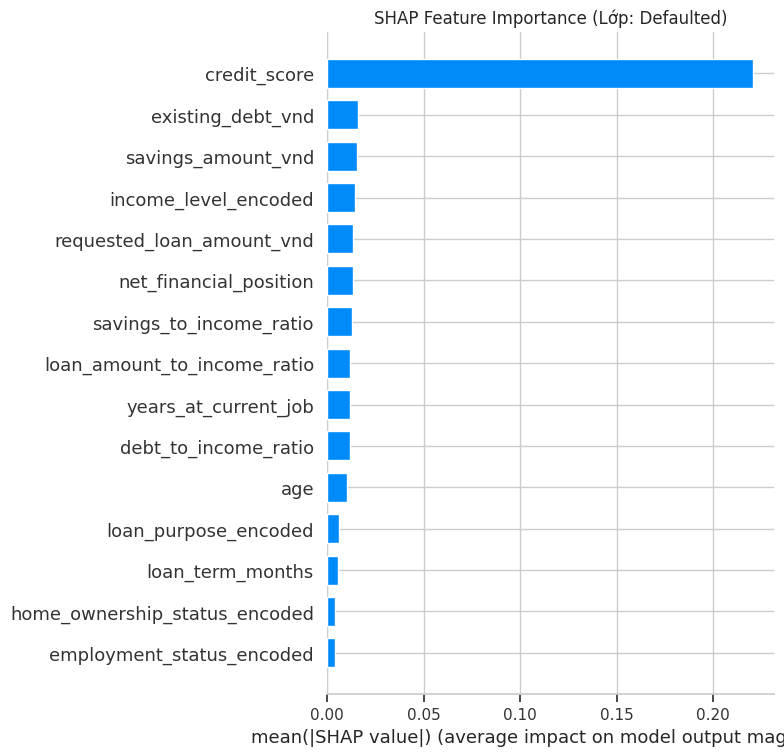

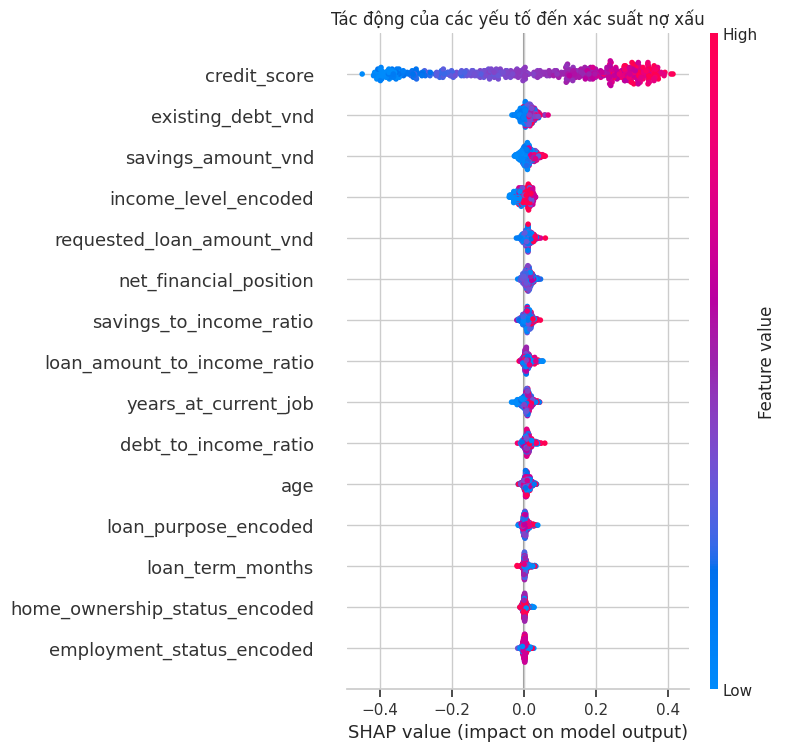

In [35]:
import shap
import numpy as np

# 1. Khởi tạo SHAP Explainer
explainer = shap.TreeExplainer(model)

# 2. Tính toán SHAP values
# Lấy mẫu 500 dòng từ tập test đã chuẩn hóa
X_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_sample)

# Kiểm tra cấu trúc shap_values để tránh lỗi AssertionError
# Đối với binary classification trong Random Forest, shap_values có thể là list [n_samples, n_features, 2]
# hoặc [2, n_samples, n_features]. Ta cần lấy index 1 (Defaulted).
if isinstance(shap_values, list):
    # Nếu là list, lấy mảng ứng với class 1
    shap_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Nếu là mảng 3 chiều, lấy slice cuối cùng
    shap_to_plot = shap_values[:, :, 1]
else:
    # Trường hợp còn lại
    shap_to_plot = shap_values

# 3. Trực quan hóa Summary Plot (Bar)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_to_plot, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Lớp: Defaulted)")
plt.show()

# 4. Summary Plot (Beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_to_plot, X_sample, show=False)
plt.title("Tác động của các yếu tố đến xác suất nợ xấu")
plt.show()

### **Insight từ SHAP:**

*   **Credit Score:** Có tác động mạnh nhất. Giá trị Credit Score thấp (màu xanh) đẩy xác suất nợ xấu lên cao (SHAP value dương).
*   **Savings Amount:** Các khách hàng có tiết kiệm thấp có xu hướng bị mô hình đánh giá rủi ro cao hơn.
*   **Net Financial Position:** Khẳng định lại giả thuyết của chúng ta về 'Hidden Gems' - vị thế tài chính ròng dương giúp kéo giảm xác suất nợ xấu một cách đáng kể.

/tmp/ipykernel_807/4114715420.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=score_data, x='Nhóm', y='Điểm', ax=axes[1], palette=['#A0A0A0', '#E74C3C'])


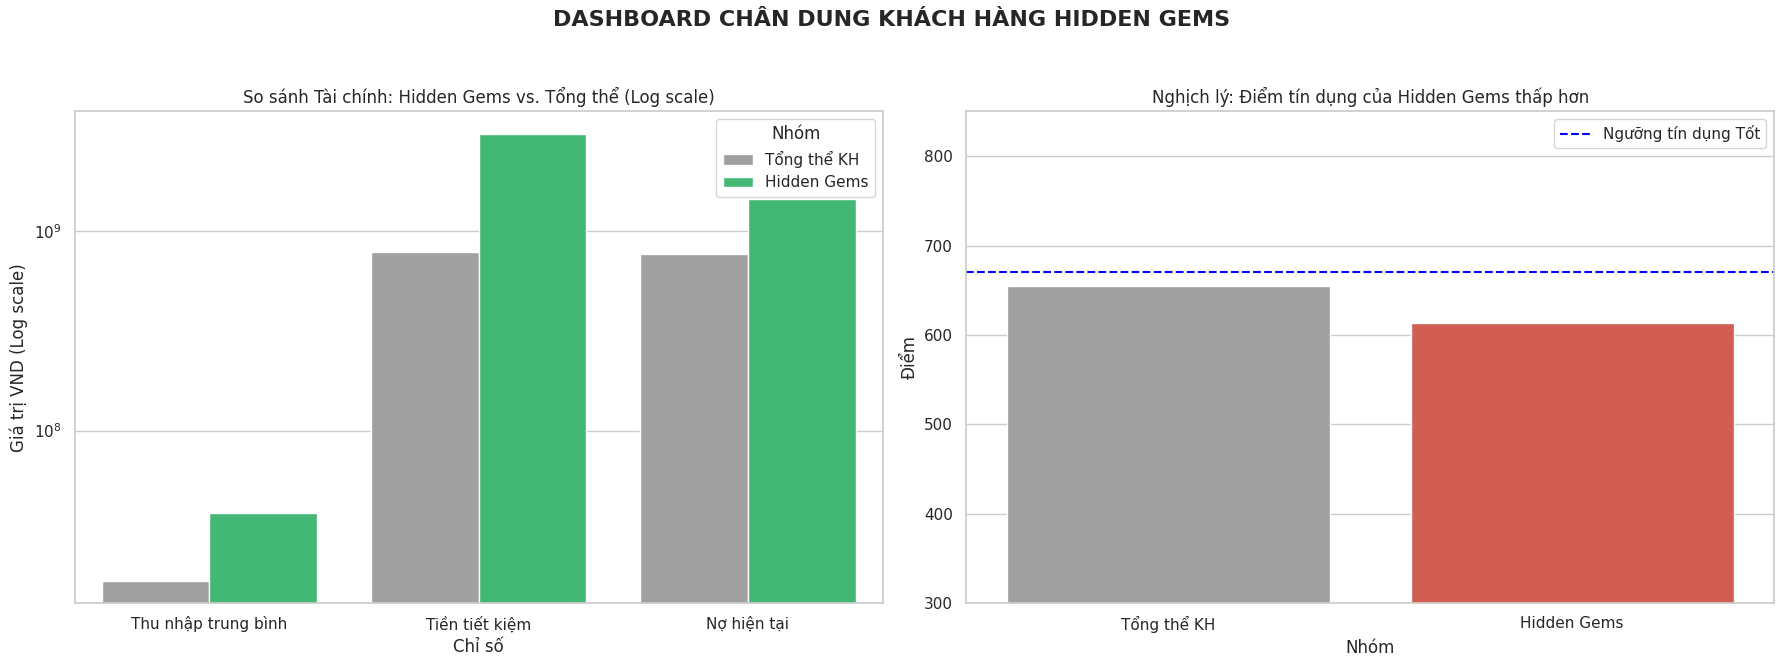

--- TÓM TẮT CHÂN DUNG ---
1. Thu nhập: Cao hơn trung bình 2.2 lần.
2. Tiết kiệm: Cao hơn trung bình 3.9 lần.
3. Nợ: Thấp hơn trung bình 0.5 lần.
4. Điểm tín dụng: Thấp hơn 42 điểm so với mặt bằng chung.


In [36]:
# 1. Chuẩn bị dữ liệu so sánh
avg_total = df[['income_level_numeric', 'credit_score', 'savings_amount_vnd', 'existing_debt_vnd']].mean()
avg_gems = untapped_segment[['income_level_numeric', 'credit_score', 'savings_amount_vnd', 'existing_debt_vnd']].mean()

comparison_df = pd.DataFrame({
    'Chỉ số': ['Thu nhập trung bình', 'Điểm tín dụng', 'Tiền tiết kiệm', 'Nợ hiện tại'],
    'Tổng thể KH': [avg_total['income_level_numeric'], avg_total['credit_score'], avg_total['savings_amount_vnd'], avg_total['existing_debt_vnd']],
    'Hidden Gems': [avg_gems['income_level_numeric'], avg_gems['credit_score'], avg_gems['savings_amount_vnd'], avg_gems['existing_debt_vnd']]
})

# 2. Vẽ Dashboard chân dung
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Biểu đồ cột so sánh Thu nhập và Tài sản (Log scale để dễ nhìn)
metrics_to_plot = ['Thu nhập trung bình', 'Tiền tiết kiệm', 'Nợ hiện tại']
plot_data = comparison_df[comparison_df['Chỉ số'].isin(metrics_to_plot)].melt(id_vars='Chỉ số', var_name='Nhóm', value_name='Giá trị (VND)')

sns.barplot(data=plot_data, x='Chỉ số', y='Giá trị (VND)', hue='Nhóm', ax=axes[0], palette=['#A0A0A0', '#2ECC71'])
axes[0].set_yscale('log')
axes[0].set_title('So sánh Tài chính: Hidden Gems vs. Tổng thể (Log scale)')
axes[0].set_ylabel('Giá trị VND (Log scale)')

# Biểu đồ so sánh Điểm tín dụng (Vốn là điểm yếu của Gems)
score_data = comparison_df[comparison_df['Chỉ số'] == 'Điểm tín dụng'].melt(id_vars='Chỉ số', var_name='Nhóm', value_name='Điểm')
sns.barplot(data=score_data, x='Nhóm', y='Điểm', ax=axes[1], palette=['#A0A0A0', '#E74C3C'])
axes[1].set_ylim(300, 850)
axes[1].set_title('Nghịch lý: Điểm tín dụng của Hidden Gems thấp hơn')
axes[1].axhline(670, color='blue', linestyle='--', label='Ngưỡng tín dụng Tốt')
axes[1].legend()

plt.suptitle('DASHBOARD CHÂN DUNG KHÁCH HÀNG HIDDEN GEMS', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"--- TÓM TẮT CHÂN DUNG ---")
print(f"1. Thu nhập: Cao hơn trung bình {(avg_gems['income_level_numeric']/avg_total['income_level_numeric']):.1f} lần.")
print(f"2. Tiết kiệm: Cao hơn trung bình {(avg_gems['savings_amount_vnd']/avg_total['savings_amount_vnd']):.1f} lần.")
print(f"3. Nợ: Thấp hơn trung bình {(avg_total['existing_debt_vnd']/avg_gems['existing_debt_vnd']):.1f} lần.")
print(f"4. Điểm tín dụng: Thấp hơn {(avg_total['credit_score'] - avg_gems['credit_score']):.0f} điểm so với mặt bằng chung.")

## **Ứng dụng Ma trận Thị phần - Tăng trưởng (Growth-Share Matrix)**

Để định hướng chiến lược tăng trưởng và quản lý rủi ro, chúng ta sẽ phân loại các phân khúc khách hàng theo Ma trận Thị phần - Tăng trưởng (Growth-Share Matrix), dựa trên tiềm năng tăng trưởng doanh thu (thị phần có thể mở rộng) và rủi ro vỡ nợ (tỷ lệ nợ xấu).

### **1. Phân khúc Ngôi sao (Stars - Growth Potential: High, Risk: Low)**
*   **Chân dung:** Tương ứng với **Cụm 2** và nhóm khách hàng có **Thu nhập Cao/Rất cao + Điểm tín dụng Xuất sắc**.
    *   **Đặc điểm nổi bật:** Tỷ lệ nợ xấu rất thấp (Cụm 2 chỉ ~13.9%), thu nhập cao, điểm tín dụng tốt (trung bình 712.87), vị thế tài chính ròng dương và khả năng tiết kiệm vượt trội.
    *   **Thách thức:** Quy mô tệp khách hàng nhỏ (1737 người).
*   **Đề xuất chiến lược:**
    *   **Tập trung Đầu tư:** Đầu tư mạnh vào việc duy trì và phát triển mối quan hệ. Cung cấp các gói sản phẩm tài chính cao cấp, đa dạng (vay tiêu dùng lớn, vay mua nhà/xe với ưu đãi đặc biệt).
    *   **'One-click Lending':** Tự động hóa hoàn toàn quy trình phê duyệt với hạn mức cao, lãi suất cạnh tranh để giữ chân và biến họ thành kênh quảng bá 'truyền miệng' cho FinInnovate.
    *   **Upselling/Cross-selling:** Giới thiệu các sản phẩm bảo hiểm, đầu tư, quản lý tài sản.

### **2. Phân khúc Bò sữa (Cash Cows - Growth Potential: Moderate, Risk: Moderate-Low)**
*   **Chân dung:** Tương ứng với **Cụm 0** và nhóm khách hàng có **Thu nhập Trung bình/Cao + Điểm tín dụng Tốt**.
    *   **Đặc điểm nổi bật:** Tỷ lệ nợ xấu ở mức kiểm soát (~19.0%), quy mô lớn nhất (16701 người), thu nhập ổn định, điểm tín dụng tốt (trung bình 691.84). Đây là nguồn doanh thu ổn định và đáng tin cậy.
    *   **Thách thức:** Khó tạo đột phá về tăng trưởng thị phần do đã khá bão hòa.
*   **Đề xuất chiến lược:**
    *   **Tối ưu hóa Lợi nhuận:** Duy trì các sản phẩm vay hiện có, nhưng tối ưu hóa chi phí vận hành và quản lý rủi ro.
    *   **Loyalty Programs:** Chương trình khách hàng thân thiết, giảm nhẹ lãi suất cho khách hàng vay lại, tăng cường trải nghiệm người dùng để duy trì lòng trung thành.
    *   **Phát triển sản phẩm phụ trợ:** Cung cấp các dịch vụ giá trị gia tăng khác để tăng doanh thu trên mỗi khách hàng (ARPU).

### **3. Phân khúc Dấu hỏi (Question Marks - Growth Potential: High, Risk: Uncertain/Potentially High)**
*   **Chân dung:** Đây chính là nhóm **'Hidden Gems'** mà chúng ta đã phát hiện: **Khách hàng có thu nhập cao, vị thế tài chính ròng dương nhưng điểm tín dụng thấp** (do thiếu lịch sử vay truyền thống).
    *   **Đặc điểm nổi bật:** Quy mô tiềm năng (2628 khách hàng, 5.26% tổng tệp), thu nhập và tiết kiệm vượt trội (cao hơn 2.2-3.9 lần so với trung bình), nhưng điểm tín dụng thấp hơn 42 điểm so với mặt bằng chung.
    *   **Thách thức:** Hệ thống chấm điểm truyền thống đánh giá họ là rủi ro cao (tỷ lệ nợ xấu của nhóm này trong dữ liệu hiện tại là 42.66% nếu chỉ nhìn vào điểm tín dụng cũ), cần phương pháp tiếp cận mới.
*   **Đề xuất chiến lược:**
    *   **Chiến lược 'Đại dương xanh':** FinInnovate có thể đi tiên phong khai thác phân khúc này bằng cách sử dụng **mô hình chấm điểm dựa trên dòng tiền (Cash-flow based lending)** và tài sản tích lũy (tiết kiệm), thay vì chỉ dựa vào lịch sử tín dụng CIC truyền thống.
    *   **Sản phẩm 'Credit Builder':** Thiết kế các sản phẩm tín dụng với hạn mức ban đầu vừa phải, lãi suất hợp lý để họ xây dựng lịch sử tín dụng với FinInnovate. Cung cấp thẻ tín dụng ảo dựa trên số dư tài khoản.
    *   **Tái thẩm định định kỳ:** Theo dõi sát sao và tái thẩm định sau 3-6 tháng để nhanh chóng nâng hạn mức nếu hành vi trả nợ tốt.

### **4. Phân khúc Chó mực (Dogs - Growth Potential: Low, Risk: High)**
*   **Chân dung:** Tương ứng với **Cụm 1** và nhóm khách hàng có **Thu nhập Thấp + Điểm tín dụng Kém/Trung bình**.
    *   **Đặc điểm nổi bật:** Tỷ lệ nợ xấu cao nhất (~38.4%), thu nhập thấp, điểm tín dụng thấp (trung bình 632.21), gánh nặng nợ trên thu nhập cao.
    *   **Thách thức:** Rủi ro cao, lợi nhuận thấp, chi phí thu hồi nợ lớn.
*   **Đề xuất chiến lược:**
    *   **Hạn chế Rủi ro:** Giảm thiểu tiếp xúc với phân khúc này. Nếu cấp vay, chỉ nên là các khoản vay siêu nhỏ (micro-loans) với điều kiện nghiêm ngặt, hoặc yêu cầu tài sản đảm bảo/người bảo lãnh rõ ràng.
    *   **Chương trình giáo dục tài chính:** Cung cấp các khóa học/tư vấn tài chính miễn phí để nâng cao kiến thức cho họ, với hy vọng một phần có thể chuyển sang nhóm 'Dấu hỏi' hoặc 'Bò sữa' trong tương lai.
    *   **Chiến lược thu hồi nợ hiệu quả:** Áp dụng các biện pháp thu hồi nợ chủ động và linh hoạt để giảm thiểu tổn thất.

### **Tổng kết**

Bằng việc áp dụng Ma trận Growth-Share, FinInnovate có thể phát triển một chiến lược tín dụng linh hoạt và thông minh, không chỉ quản lý tốt rủi ro mà còn khai phá được các phân khúc thị trường ngách tiềm năng, tạo lợi thế cạnh tranh bền vững trong bối cảnh thị trường biến động.

# **8. Đề xuất Chiến lược Kinh doanh (Business Recommendations)**

#### **1. Bối cảnh Vĩ mô & 'Điểm chạm' Thị trường (Vietnam 2024-2025)**
Trong giai đoạn Ngân hàng Nhà nước (NHNN) tăng cường kiểm soát rủi ro hệ thống, đặc biệt là các khoản vay thế chấp bất động sản và tín dụng doanh nghiệp, thị trường đang chứng kiến một cuộc **'Siết tín dụng' (Credit Crunch)** cục bộ.

*   **Rào cản truyền thống:** Các ngân hàng TMCP đang siết chặt điều kiện giải ngân, yêu cầu chứng minh thu nhập khắt khe và tài sản đảm bảo chất lượng cao.
*   **Cơ hội cho FinInnovate:** Khi 'cửa' ngân hàng hẹp lại, nhu cầu tiêu dùng và kinh doanh nhỏ vẫn hiện hữu. Đây là thời điểm vàng để chúng ta triển khai chiến lược **Đại dương xanh (Blue Ocean Strategy)**.

#### **2. Chiến lược 'Lách' qua dữ liệu phi truyền thống**
Thay vì đối đầu trực tiếp với các ngân hàng ở phân khúc khách hàng truyền thống (vốn đang bị siết chặt), FinInnovate tập trung vào:
*   **Thẩm định bằng niềm tin dữ liệu:** Sử dụng AI/ML để khai phá các 'Hidden Gems' - những người có khả năng chi trả nhưng thiếu tài sản thế chấp hoặc lịch sử tín dụng CIC cũ.
*   **Tốc độ & Linh hoạt:** Trong khi ngân hàng mất nhiều tuần để thẩm định, mô hình Random Forest của chúng ta cho phép ra quyết định trong vài phút, trực tiếp giải quyết 'nỗi đau' về thời gian của khách hàng trong bối cảnh khan hiếm dòng vốn.

#### **3. Tầm nhìn chiến lược**
Việc FinInnovate nhảy vào thị trường lúc này không chỉ là mở rộng kinh doanh, mà là **tái định nghĩa khả năng tiếp cận tài chính**. Chúng ta không dựa vào tài sản thế chấp (Asset-based), mà dựa vào **năng lực tài chính thực tế và hành vi (Behavioral-based)**, biến rủi ro của hệ thống truyền thống thành cơ hội độc quyền của Fintech.

### **CHIẾN LƯỢC CẠNH TRANH ĐỘT PHÁ**
*   **Đối đầu với Ngân hàng (Conventional Banks):** Tập trung vào tốc độ phê duyệt (dưới 5 phút) và không yêu cầu chứng minh thu nhập cứng nhắc - điểm yếu cố hữu của ngân hàng.
*   **Đối đầu với Fintech khác:** Tối ưu hóa mô hình Random Forest để giảm tỷ lệ từ chối nhầm, từ đó cung cấp mức lãi suất cạnh tranh hơn 2-3% so với các app vay tiêu dùng hiện nay.
*   **Hành động:** Tập trung nguồn lực vào phân khúc **'Stars'** (Thẻ tín dụng Gen Z/Chuyên gia trẻ) - nơi có tốc độ tăng trưởng cực cao tại đô thị Việt Nam.